In [1]:
from pathlib import Path
from typing import Iterable, Sequence
import warnings
import sys
import numpy as np
import pandas as pd
import xarray as xr
import regionmask as regmask
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from ILAMB import ilamblib

import xclimate as xclim
from load_cmip_esgf import CMIPESGFLoader

sys.path.insert(0, "/glade/u/home/bbuchovecky/projects/et_controls/lai_ai_binning")
from ppe_2d_binning import _build_edges, _bin_stats_single_member

# Dask

In [2]:
DASK_WORKERS = 4
DASK_MEMORY = "32GB"
DASK_WALLTIME = "01:00:00"


client_cluster = xclim.create_dask_cluster(
    account="UWAS0155",
    nworkers=DASK_WORKERS,
    ncores=DASK_WORKERS,
    nmem=DASK_MEMORY,
    walltime=DASK_WALLTIME,
)
client_cluster[0].wait_for_workers(DASK_WORKERS)

account:  UWAS0155
nworkers: 4
ncores:   4
nmemory:  32GB
walltime: 01:00:00
{'PBSCluster-0': <dask_jobqueue.pbs.PBSJob: status=running>}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 8787:128.117.211.162:8787 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:8787/status


# Constants

In [3]:
# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------

PROC_ROOTS = {
    "fppe": Path("/glade/work/bbuchovecky/et_unc/proc/fppe"),   # FHIST PPE
    "ippe": Path("/glade/work/bbuchovecky/et_unc/proc/ippe"),   # IHIST PPE
    "goga": Path("/glade/work/bbuchovecky/et_unc/proc/goga2"),  # CESM2 GOGA2
    "lens": Path("/glade/work/bbuchovecky/et_unc/proc/lens2"),  # CESM2 LENS2
    "cmip": Path("/glade/work/bbuchovecky/et_unc/proc/cmip6"),  # CMIP6
    "obs":  Path("/glade/work/bbuchovecky/et_unc/proc/obs"),    # observations (ILAMB)
}
SUBDIRS = [
    "trends",
    "time_mean",
    "zonal_mean",
    "binned",
]
BIN_EDGES_ROOT = Path("/glade/work/bbuchovecky/et_unc/proc/qbin_edges")


# ------------------------------------------------------------------
# Settings for plotting
# ------------------------------------------------------------------

# Save figures as {'fppe.CESM2.*.png', 'ippe.CESM2.*.png', 'goga2.CESM2.*.png',
# 'lens2.CESM2.*.png', 'cmip6.<model>.*.png', 'obs.<product>.*.png'}
FIG_ROOT = Path("/glade/work/bbuchovecky/et_unc/fig")
PROJECTION = ccrs.PlateCarree()
LAT_BNDS = slice(-58, 90)
DPI = 120

CESM_TITLES = {
    "fppe": "FHIST PPE",
    "ippe": "IHIST PPE",
    "goga": "GOGA2",
    "lens": "LENS2",
}


# ------------------------------------------------------------------
# Settings for analysis
# ------------------------------------------------------------------

# Binned mean ET plots
N_XBINS = 15
N_YBINS = 15

# Masking and grid things
LF_THRESH = 0.5  # gridcell land fraction threshold
LAT_INTERP_GRID = np.arange(-90, 91, 1)  # 1-deg latitude array to interpolate zonal mean

# Scientific constants
LATENT_HEAT_VAPORIZATION = 2.45e6  # J/kg
LIQ_WATER_DENSITY = 1e3            # kg/m3

# Variables to load
FPPE_VARIABLES = ["PRECT_month_1", "TLAI_month_1", "EFLX_LH_TOT_month_1", "FLNS_month_1", "FSNS_month_1", "FSH_month_1"]
CESM_VARIABLES = ["PRECC_month_1", "PRECL_month_1", "TLAI_month_1", "EFLX_LH_TOT_month_1", "TLAI_month_1", "FLNS_month_1", "FSNS_month_1", "FSH_month_1"]
CMIP_VARIABLES = ["pr", "lai", "evspsbl", "rlds", "rsds", "rlus", "rsus", "hfss"]
ILAMB_VARIABLES = ["et", "lai"]
ERA_VARIBLES = ["mer", "msnswrf", "msnlwrf", "mtpr"]


FPPE_SETTINGS = {
    "TIME_SLICE": slice("1995-01", "2014-12"),
}

GOGA_SETTINGS = {
    "GCOMP": "lnd",
    "STREAM": "h0",
    "TIME_SLICE": slice("1995-01", "2014-12"),
}

LENS_SETTINGS = {
    "GCOMP": "lnd",
    "STREAM": "h0",
    "TIME_SLICE": slice("1995-01", "2014-12"),
}

CMIP_SETTINGS = {
    "EXPERIMENT_ID":      "historical",
    "MEMBER_ID":          "top",
    "SOURCE_IDS":         None,
    "OMIT_SOURCE_IDS":    ["EC-Earth3", "EC-Earth3-AerChem", "EC-Earth3-ESM-1", "EC-Earth3-HR", "EC-Earth3-Veg-LR"],
    "CATALOG":            Path("/glade/campaign/univ/uwas0155/catalogs/cmip6_all.csv"),
    "TIME_SLICE":         slice("1995-01", "2014-12"),
    "GRID_VARIABLES":     ["areacella", "sftlf"],
}

ILAMB_SETTINGS = {
    "ROOT": Path("/glade/campaign/univ/uwas0155/obs/ilamb"),
    "PRODUCTS": {
        "et": [
            "CLASS",
            "DOLCE",
            "FLUXCOM",
            "GLEAMv3.3a",
            "MODIS",
            "MOD16A2",
            # "WECANN",
        ],
        "lai": [
            "AVHRR",
            "AVH15C1",
            "GIMMS_LAI4g", 
            "MODIS",
        ]
    },
    "TIME_SLICE": slice(None, None),
}

ERA_SETTINGS = {
    "ROOT": Path("/glade/campaign/univ/uwas0155/obs/era5/regridded"),
    "KIND": "meanflux",
    "TIME_SLICE": slice("1980-01", "2014-12"),
    "RESOLUTION": "regridded_0.5_deg",
}

# Functions

In [4]:
# ------------------------------------------------------------------
# General helpers
# ------------------------------------------------------------------

def parse_time_string(time_str: str) -> tuple[int, ...]:
    """
    Parse time string with format 'year-month-day', 'year-month', or 'year'
    to a tuple of integers with format (year, month, day). If month or day are
    not included, sets them to 1 by default.
    """

    time_str_split = time_str.split("-")
    if len(time_str_split) == 2:
        time_str_split += ["01"]
    elif len(time_str_split) == 1:
        time_str_split += ["01", "01"]
    elif (len(time_str_split) > 3) or (len(time_str_split) == 0):
        raise ValueError("Time string must contain year, month, or day.")
    return tuple(int(s) for s in time_str_split)


def get_one_mid(da: xr.DataArray) -> str:
    if ("member" in da.dims):
        if ("member_id" in da.coords):
            return str(da.member_id[0].item())
    return "onemember"


def _safe_squeeze(da: xr.DataArray, dim: str, drop: bool = True):
    if dim in da.dims:
        return da.squeeze(dim=dim, drop=drop)
    return da


def to_yyyymm(time) -> str:
    time_raw = time.values
    if isinstance(time_raw, np.datetime64):
        return pd.Timestamp(time_raw).strftime("%Y%m")
    elif isinstance(time_raw, np.ndarray):
        return time.item().strftime("%Y%m")
    raise TypeError(f"Unsupported type {type(time)!r} for time")


def check_same_grid(da: xr.DataArray, ref: xr.DataArray | xr.Dataset, label: str, atol: float = 1e-3) -> None:
    """Assert `da` shares its lat/lon grid with `ref`; fail loudly rather than silently reindex."""
    if da.sizes.get("lat") != ref.sizes.get("lat") or da.sizes.get("lon") != ref.sizes.get("lon"):
        raise ValueError(
            f"{label}: grid shape lat={da.sizes.get('lat')}, lon={da.sizes.get('lon')} does not match "
            f"the reference ERA5 grid lat={ref.sizes.get('lat')}, lon={ref.sizes.get('lon')}. "
            "ILAMB and ERA5 were assumed to already share a grid."
        )
    if not np.allclose(da.lat.values, ref.lat.values, atol=atol) or not np.allclose(da.lon.values, ref.lon.values, atol=atol):
        raise ValueError(
            f"{label}: lat/lon coordinate values differ from the reference ERA5 grid by more than {atol}. "
            "ILAMB and ERA5 were assumed to already share a grid."
        )


def compute_cell_area(ds):
    land = regmask.defined_regions.natural_earth_v5_1_2.land_50

    if "lat_bounds" in ds and "lon_bounds" in ds:
        method = "bounds"
        lat_bounds = ds["lat_bounds"].values
        lon_bounds = ds["lon_bounds"].values
    else:
        method = "coords"
        lat_bounds = None
        lon_bounds = None

    area = ilamblib.CellAreas(
        lat=ds["lat"].values,
        lon=ds["lon"].values,
        lat_bnds=lat_bounds,
        lon_bnds=lon_bounds,
    )

    area = xr.DataArray(area, dims=["lat", "lon"], coords={"lat": ds["lat"], "lon": ds["lon"]})
    area.attrs["units"] = "m2"
    area.attrs["long_name"] = "grid cell area"
    area.attrs["method"] = method

    mask = xr.where(np.isnan(land.mask(lon_or_obj=area.lon, lat=area.lat)), 0, 1)
    la = area * mask
    la.attrs["units"] = "m2"
    la.attrs["long_name"] = "land grid cell area"
    la.attrs["method"] = method

    return area, la


def mask_greenland(landfrac: xr.DataArray, lf_thresh: float) -> xr.DataArray:
    mask = regmask.defined_regions.ar6.land.mask(landfrac.lon, landfrac.lat)
    return xr.where((mask == 0) & (landfrac > lf_thresh), False, landfrac > lf_thresh)


# ------------------------------------------------------------------
# Plotting
# ------------------------------------------------------------------

def add_gridlines(ax, lat_bnds):
    x_gls = np.arange(-180, 181, 30)
    y_gls = np.arange(-90, 91, 30)
    y_gls = y_gls[(y_gls >= lat_bnds.start) & (y_gls <= lat_bnds.stop)]
    ax.gridlines(
        draw_labels=False,
        xlocs=x_gls,
        ylocs=y_gls,
        linewidth=0.5,
        color="gray",
        alpha=0.6,
        linestyle="--",
    )


def quick_map(da: xr.DataArray, fout: Path, title: str = "", robust: bool = True, vmin: float = 0, **kwargs):
    fig, ax = plt.subplots(figsize=(8, 3), layout="constrained", subplot_kw={"projection": PROJECTION})
    da.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", vmin=vmin, robust=robust, **kwargs)
    ax.set_title(title)
    ax.coastlines(color="k", lw=0.8)
    ax.set_extent((-180, 180, LAT_BNDS.start, LAT_BNDS.stop), crs=PROJECTION)
    add_gridlines(ax, LAT_BNDS)
    fig.savefig(fout, dpi=DPI, bbox_inches="tight")
    plt.close()


def plot_edges(edges, out):
    fig, axs = plt.subplots(2, 1, layout="constrained")
    edges.plot(ax=axs[0], marker="o")
    edges[1:-1].plot(ax=axs[1], marker="o")
    for ax in axs:
        ax.set_xlim(0, len(edges))
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.close()


# ------------------------------------------------------------------
# Analysis
# ------------------------------------------------------------------

def compute_annual_mean(da):
    days_in_month = da.time.dt.days_in_month
    weights = days_in_month.groupby('time.year') / days_in_month.groupby('time.year').sum()
    with xr.set_options(keep_attrs=True):
        return (da * weights).groupby('time.year').sum()


def compute_aridity_index(
    precip_wm2: xr.DataArray,
    rn: xr.DataArray,
    clip: bool = False,
) -> xr.DataArray:
    """
    Compute the annual mean aridity index, AI = Rn / (L*P).

    Parameters
    ----------
    precip_wm2 : xr.DataArray
        Annual mean precipitation expressed as an energy flux, L*P [W/m2].
    rn : xr.DataArray
        Annual mean net surface radiation [W/m2], used as a proxy for
        PET (PET ~ Rn) per the Budyko framework.
    clip : bool, optional
        If True, floor `rn` at zero before dividing.
    """
    if clip:
        rn = rn.clip(min=0)
    ai = rn / precip_wm2
    ai = ai.rename("AI")
    ai.attrs = {
        "long_name": "Budyko dryness index (Rn / L*P)",
        "description": (
            "computed from ERA5 annual mean net surface radiation and "
            f"precipitation{' (Rn floor at zero)' if clip else ''}"
        ),
    }
    return ai


# ------------------------------------------------------------------
# Data loading
# ------------------------------------------------------------------

def data_dict_nybtes(data_dict):
    total_ngb = 0
    sid_ngb = {}
    for sid, vardict in data_dict.items():
        sid_ngb[sid] = 0
        for var, da in vardict.items():
            sid_ngb[sid] += da.nbytes / 1024 / 1024 / 1024
        total_ngb += sid_ngb[sid]
    
    print(f"total: {total_ngb:0.3f} GB")
    for sid, ngb in sid_ngb.items():
        print(f"{sid:20}: {ngb:0.3f} GB")
    

def check_coords(da: xr.DataArray, coords: Iterable[str]) -> bool:
    """Check that da has coords."""
    for coord in coords:
        if coord not in da.coords:
            return False
        if da[coord].ndim == 0:
            continue  # scalar coord counts as present
        if len(da[coord]) == 0:
            return False
    return True


def equal_coords(
    a: xr.DataArray,
    b: xr.DataArray,
    coords: Iterable[str],
    atol: float = 1e-3
) -> bool:
    """Check that a and b have the same coords."""
    if not check_coords(a, coords) or not check_coords(b, coords):
        return False
    for crd in coords:
        if a[crd].shape != b[crd].shape:
            return False
        if crd != "time":  # should actually check if dtype is numeric
            if not np.allclose(a[crd], b[crd], atol=atol):
                return False
    return True


def convert_units(v, da):
    """Convert to water flux units to energy equivalent W/m2."""

    # CESM2: precip from m/s -> W/m2
    if v in ("PRECT_calculated_month_1", "PRECT_month_1", "PRECT_calculated", "PRECT"):
        print("Converting units from m/s -> W/m2")
        da = da * LATENT_HEAT_VAPORIZATION * LIQ_WATER_DENSITY
        da.attrs["units"] = "W/m2"

    # CMIP6, ERA5, ILAMB: precip and et from kg/m2/s -> W/m2
    if v in ("pr", "evspsbl", "mtpr", "mer", "et"):
        print("Converting units from kg/m2/s -> W/m2")
        da = da * LATENT_HEAT_VAPORIZATION
        da.attrs["units"] = "W/m2"

    # ERA5: et sign convention
    if v == "mer":
        da = -1 * da

    return da


def filter_all_variables_available(
    data_dict: dict,
    variables: Sequence[str],
    coords: Iterable[str] | None = None,
) -> dict:
    sid_avail = []
    variables_set = set(variables)

    print("=== Not available ===")
    for sid, vardict in data_dict.items():
        intersection = variables_set - set(vardict.keys())
        if len(intersection) > 0:
            print(f"{sid:16}: missing {intersection}")
            continue

        good_coords = True
        test_v = variables[0]
        test_da = vardict[test_v]
        for v in variables[1:]:
            da = vardict[v]
            if coords is not None:
                if not equal_coords(da, test_da, coords):
                    good_coords = False
                    print(f"{sid:16}: {v} mismatched coords {coords} {test_da.shape} {da.shape}")
                    continue
        if good_coords:
            sid_avail.append(sid)
        
    print(f"\n=== Available: {len(sid_avail)} === ")
    print(sid_avail)

    data_dict_filt = {}
    for sid in sid_avail:
        data_dict_filt[sid] = data_dict[sid]

    return data_dict_filt

def load_fppe_variable(
    variable: str, 
    lat_bnds: slice,
    grid: xr.Dataset | xr.DataArray,
    mask: xr.DataArray | bool = True,
) -> xr.DataArray:
    if not isinstance(mask, bool) and isinstance(mask, xr.DataArray):
        assert equal_coords(mask, grid, ("lat", "lon"))
        mask = mask.reindex_like(grid, method="nearest", tolerance=1e-3)
    print(f"FPPE: Loading {variable}")
    v = "_".join(variable.split("_")[:-2])
    frq = "_".join(variable.split("_")[-2:])
    if v == "PRECT":
        v = "PRECT_calculated"
        variable = f"PRECT_calculated_{frq}"
    da = (
        xclim.load_fhist(variable, keep_var_only=False)[v]
        .sel(time=FPPE_SETTINGS["TIME_SLICE"], lat=lat_bnds)
    )
    if not equal_coords(da, grid, ("lat", "lon")):
        raise IndexError("da and grid do not have the same 'lat', 'lon' coordinates")
    if isinstance(mask, xr.DataArray) and not equal_coords(da, mask, ("lat", "lon")):
        raise IndexError("da and grid do not have the same 'lat', 'lon' coordinates")
    da = da.reindex_like(grid, method="nearest", tolerance=1e-3).where(mask)
    return convert_units(variable, da)


def load_goga2_variable(
    variable: str, 
    lat_bnds: slice,
    grid: xr.Dataset | xr.DataArray,
    mask: xr.DataArray | bool = True,
) -> xr.DataArray:
    if not isinstance(mask, bool) and isinstance(mask, xr.DataArray):
        assert equal_coords(mask, grid, ("lat", "lon"))
        mask = mask.reindex_like(grid, method="nearest", tolerance=1e-3)
    print(f"GOGA2: Loading {variable}")
    v = "_".join(variable.split("_")[:-2])
    frq = "_".join(variable.split("_")[-2:])
    da = (
        xclim.load_goga2(v, GOGA_SETTINGS["GCOMP"], frq, GOGA_SETTINGS["STREAM"])[v]
        .sel(time=GOGA_SETTINGS["TIME_SLICE"], lat=lat_bnds)
    )
    if not equal_coords(da, grid, ("lat", "lon")):
        raise IndexError("da and grid do not have the same 'lat', 'lon' coordinates")
    if isinstance(mask, xr.DataArray) and not equal_coords(da, mask, ("lat", "lon")):
        raise IndexError("da and grid do not have the same 'lat', 'lon' coordinates")
    da = da.reindex_like(grid, method="nearest", tolerance=1e-3).where(mask)
    return convert_units(variable, da)


def load_lens2_variable(
    variable: str, 
    lat_bnds: slice,
    grid: xr.Dataset | xr.DataArray,
    mask: xr.DataArray | bool = True,
    bb: str = "cmip6",
) -> xr.DataArray:
    if not isinstance(mask, bool) and isinstance(mask, xr.DataArray):
        assert equal_coords(mask, grid, ("lat", "lon"))
        mask = mask.reindex_like(grid, method="nearest", tolerance=1e-3)
    print(f"LENS2: Loading {variable}")
    v = "_".join(variable.split("_")[:-2])
    frq = "_".join(variable.split("_")[-2:])
    da = (
        xclim.load_cesm2le(v, LENS_SETTINGS["GCOMP"], frq, LENS_SETTINGS["STREAM"], bb=bb)[v]
        .sel(time=LENS_SETTINGS["TIME_SLICE"], lat=lat_bnds)
    )
    if not equal_coords(da, grid, ("lat", "lon")):
        raise IndexError("da and grid do not have the same 'lat', 'lon' coordinates")
    if isinstance(mask, xr.DataArray) and not equal_coords(da, mask, ("lat", "lon")):
        raise IndexError("da and grid do not have the same 'lat', 'lon' coordinates")
    da = da.reindex_like(grid, method="nearest", tolerance=1e-3).where(mask)
    return convert_units(variable, da)

# Load CMIP6

In [ ]:
# ------------------------------------------------------------------
# Load CMIP6
# ------------------------------------------------------------------
cmip_time_str = (
    f"{CMIP_SETTINGS['TIME_SLICE'].start.replace('-', '')}-"
    f"{CMIP_SETTINGS['TIME_SLICE'].stop.replace('-', '')}"
)

loader = CMIPESGFLoader(CMIP_SETTINGS["CATALOG"])
cmip = loader.load_data(
    variables=CMIP_VARIABLES + CMIP_SETTINGS["GRID_VARIABLES"],
    experiment_id=CMIP_SETTINGS["EXPERIMENT_ID"],
    source_id=CMIP_SETTINGS["SOURCE_IDS"],
    omit_source_id=CMIP_SETTINGS["OMIT_SOURCE_IDS"],
    member_id=CMIP_SETTINGS["MEMBER_ID"],
    time_slice=CMIP_SETTINGS["TIME_SLICE"],
    parallel=True,
    compute=False,
)
cmip = filter_all_variables_available(cmip, CMIP_VARIABLES, coords=("lat", "lon", "time"))
cmip = filter_all_variables_available(cmip, CMIP_SETTINGS["GRID_VARIABLES"], coords=None)

print("Compute land area")
for sid, vardict in cmip.items():
    if len(vardict.keys()) > 0:
        cmip[sid]["sftlf"] = cmip[sid]["sftlf"].sel(lat=LAT_BNDS)
        cmip[sid]["areacella"] = cmip[sid]["areacella"].sel(lat=LAT_BNDS)

        cmip[sid]["lf"] = cmip[sid]["sftlf"].reindex_like(cmip[sid]["areacella"], method="nearest", tolerance=1e-3)
        cmip[sid]["la"] = cmip[sid]["areacella"] * cmip[sid]["lf"]
        cmip[sid]["mask"] = mask_greenland(cmip[sid]["lf"], LF_THRESH)
        cmip[sid]["mask"] = cmip[sid]["mask"].where(~np.isnan(cmip[sid]["mask"]), other=False)
        del cmip[sid]["sftlf"]

print("Reindex analysis variables to atmospheric grid")
for sid, vardict in cmip.items():
    print(f"=== {sid} ===")
    for v, da in vardict.items():
        vardict[v] = (
            da.sel(lat=LAT_BNDS)
            .reindex_like(cmip[sid]["mask"], method="nearest", tolerance=1e-3)
            .where(cmip[sid]["mask"])
        )
        vardict[v] = convert_units(v, vardict[v])
        print(f"{v:12}: {vardict[v].dims} {vardict[v].shape}")

number of models with areacella and sftlf: 48
only selecting top member_id
=== ACCESS-CM2 ===
  evspsbl      n=1     ✅r1i1p1f1 
  lai          n=1     ❌r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlus         n=1     ✅r1i1p1f1 
  rsus         n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  areacella    n=1     ✅r1i1p1f1 
  sftlf        n=1     ✅r1i1p1f1 
=== ACCESS-ESM1-5 ===
  evspsbl      n=1     ✅r1i1p1f1 
  lai          n=1     ✅r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlus         n=1     ✅r1i1p1f1 
  rsus         n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  areacella    n=1     ✅r1i1p1f1 
  sftlf        n=1     ✅r1i1p1f1 
=== AWI-CM-1-1-MR ===
  evspsbl      n=1     ✅r1i1p1f1 
  lai          n=1     ❌r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlus         n=1     ✅r1i1p1f1 
  rsus         n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  areacella 

## LAI thresholds

In [ ]:
# cmip_lai_max = {}
# for sid, vardict in cmip.items():
#     cmip_lai_max[sid] = vardict["lai"].groupby("time.month").mean().max(dim="month").compute()

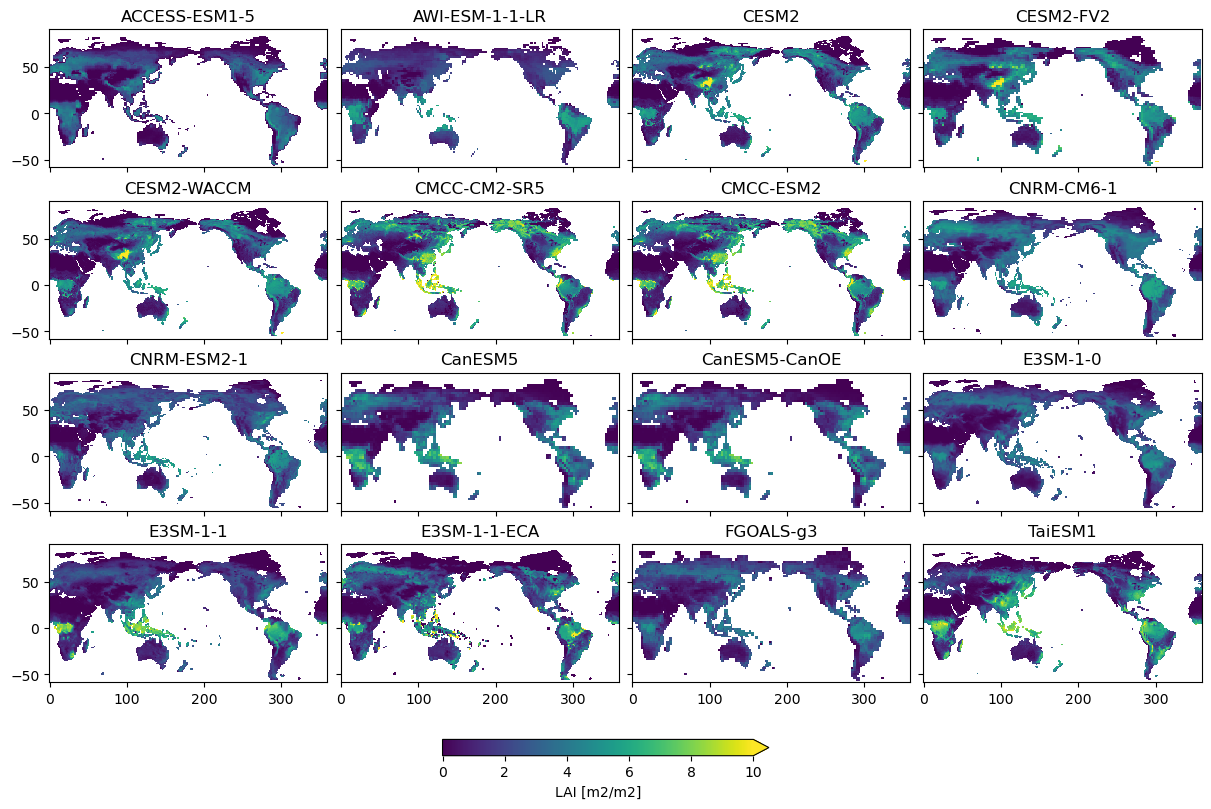

In [ ]:
# fig, axes = plt.subplots(4, 4, figsize=(12, 8), sharex=True, sharey=True, layout="constrained")
# axs = axes.ravel()

# im = None
# for i, (sid, da) in enumerate(cmip_lai_max.items()):
#     im = da.plot(ax=axs[i], vmin=0, vmax=10, add_labels=False, add_colorbar=False)
#     axs[i].set_title(sid)

# cb = fig.colorbar(im, ax=axs, orientation="horizontal", fraction=0.025, extend="max")
# cb.set_label("LAI [m2/m2]")

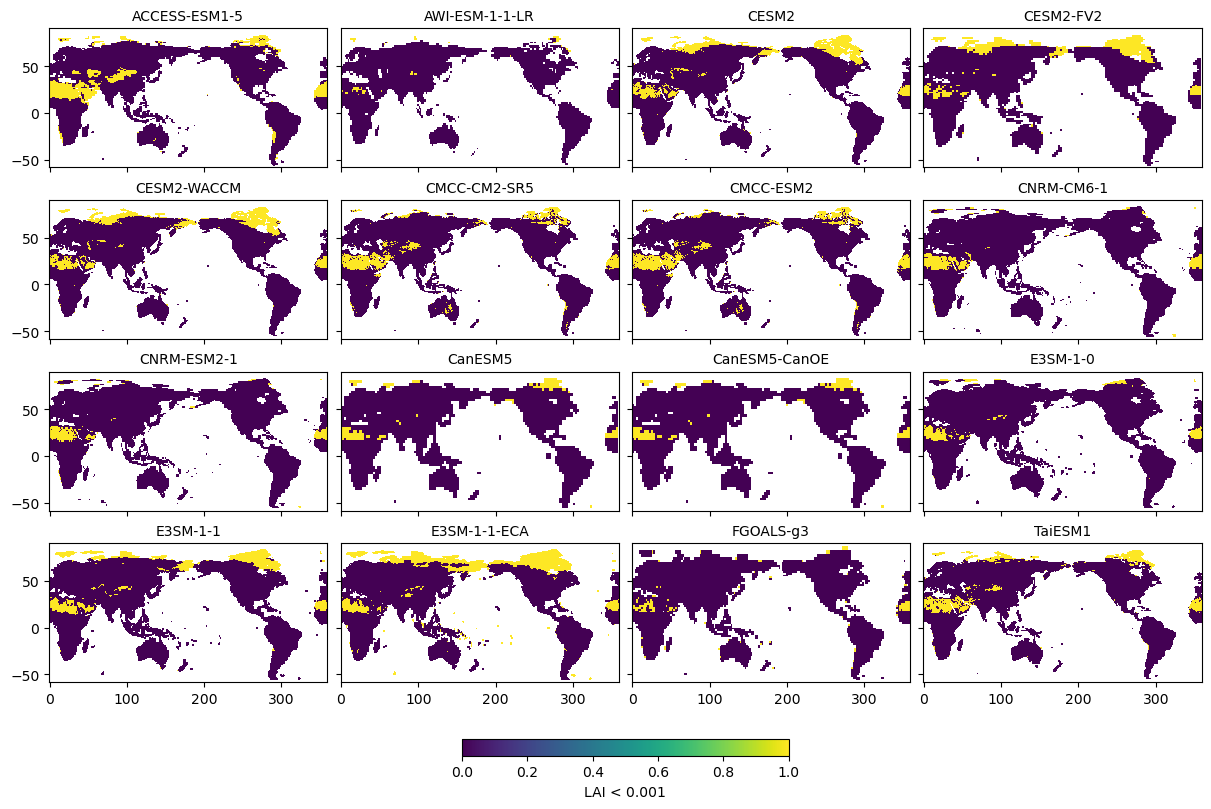

In [ ]:
# thresh = 0.001

# fig, axes = plt.subplots(4, 4, figsize=(12, 8), sharex=True, sharey=True, layout="constrained")
# axs = axes.ravel()

# im = None
# for i, (sid, da) in enumerate(cmip_lai_max.items()):
#     im = (da<thresh).where(~np.isnan(da)).plot(ax=axs[i],add_labels=False, add_colorbar=False)
#     axs[i].set_title(sid, fontsize=10)

# cb = fig.colorbar(im, ax=axs, orientation="horizontal", fraction=0.025)
# cb.set_label(f"LAI < {thresh}")

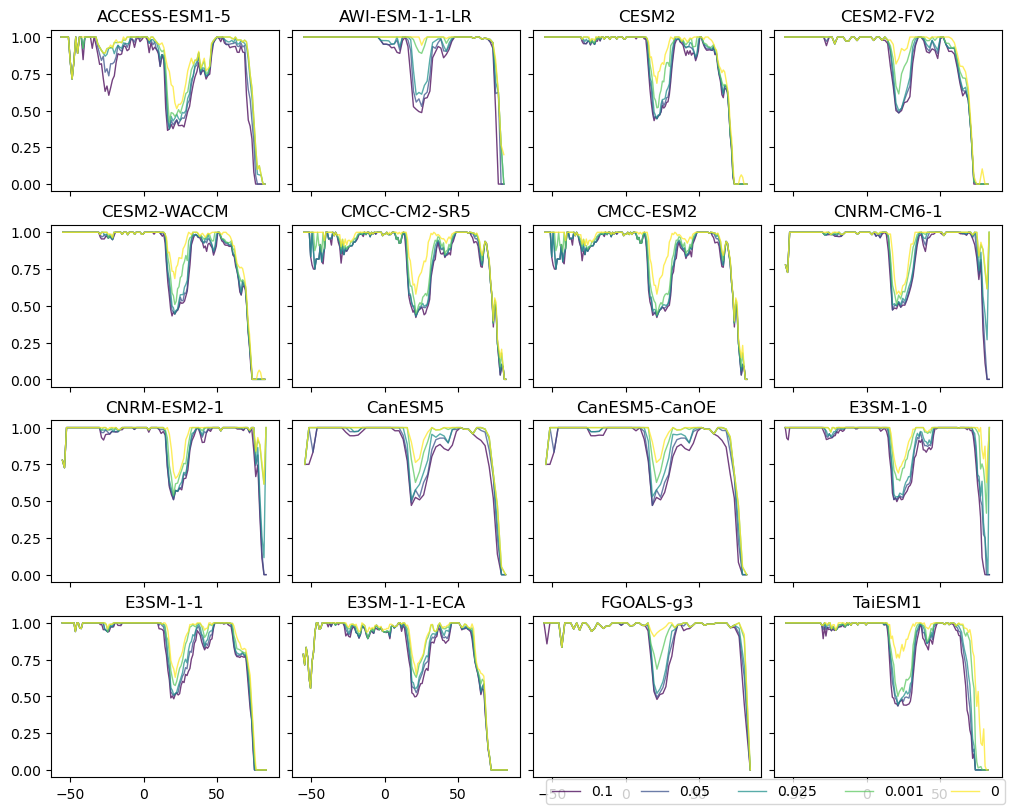

In [ ]:
# thresh_list = [0.1, 0.05, 0.025, 0.001, 0]
# colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(thresh_list)))

# fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=True, sharey=True, layout="constrained")
# axs = axes.ravel()

# im = None
# for i, (sid, da) in enumerate(cmip_lai_max.items()):
#     for c, thresh in enumerate(thresh_list):
#         da_thresh = da.where(da>thresh)
#         nvalid_zonal = (~np.isnan(da)).sum(dim="lon")
#         nvalid_zonal_thresh = (~np.isnan(da_thresh)).sum(dim="lon")
#         im = (nvalid_zonal_thresh / nvalid_zonal).plot(ax=axs[i], color=colors[c], lw=1, alpha=0.75, label=thresh, _labels=False)
#     axs[i].set_title(sid)

# h, l = axs[0].get_legend_handles_labels()
# fig.legend(h, l, loc="lower right", ncols=5)

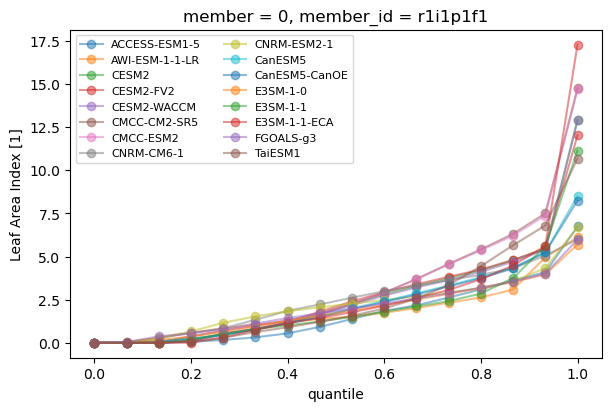

In [ ]:
# fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")

# qs_list = []
# for i, (sid, da) in enumerate(sorted(cmip_lai_max.items())):
#     qs = da.stack(stacked=["lat", "lon"]).quantile(np.linspace(0, 1, 16), dim="stacked")
#     qs_list.append(_safe_squeeze(qs, "member"))
#     qs.plot(ax=ax, marker="o", label=sid, alpha=0.5)
# ax.legend(ncols=2, fontsize=8)

# qs_da = xr.concat(qs_list, dim="source_id")

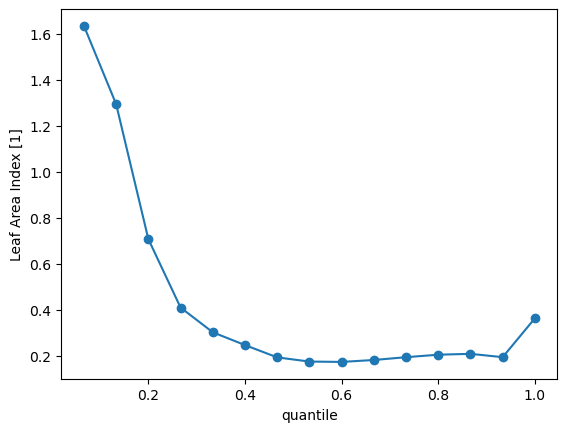

In [ ]:
# (qs_da.std(dim="source_id") / qs_da.mean(dim="source_id")).plot(marker="o")

# Load FPPE

In [5]:
# ------------------------------------------------------------------
# Load FPPE
# ------------------------------------------------------------------
fppe_time_str = (
    f"{FPPE_SETTINGS['TIME_SLICE'].start.replace('-', '')}-"
    f"{FPPE_SETTINGS['TIME_SLICE'].stop.replace('-', '')}"
)
print("Load FHIST PPE")
fppe_grid = xclim.load_fhist_ppe_grid().sel(lat=LAT_BNDS)
fppe_mask = mask_greenland(fppe_grid.LANDFRAC, LF_THRESH)
fppe = {}
for v in FPPE_VARIABLES:
    fppe[v] = load_fppe_variable(v, LAT_BNDS, fppe_grid, mask=fppe_mask)

Load FHIST PPE
FPPE: Loading PRECT_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27
Converting units from m/s -> W/m2
FPPE: Loading TLAI_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27
FPPE: Loading EFLX_LH_TOT_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27
FPPE: Loading FLNS_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27
FPPE: Loading FSNS_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27
FPPE: Loading FSH_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27


## LAI thresholds

In [ ]:
# fppe_lai_max = fppe["TLAI_month_1"].groupby("time.month").mean().max(dim="month").compute()

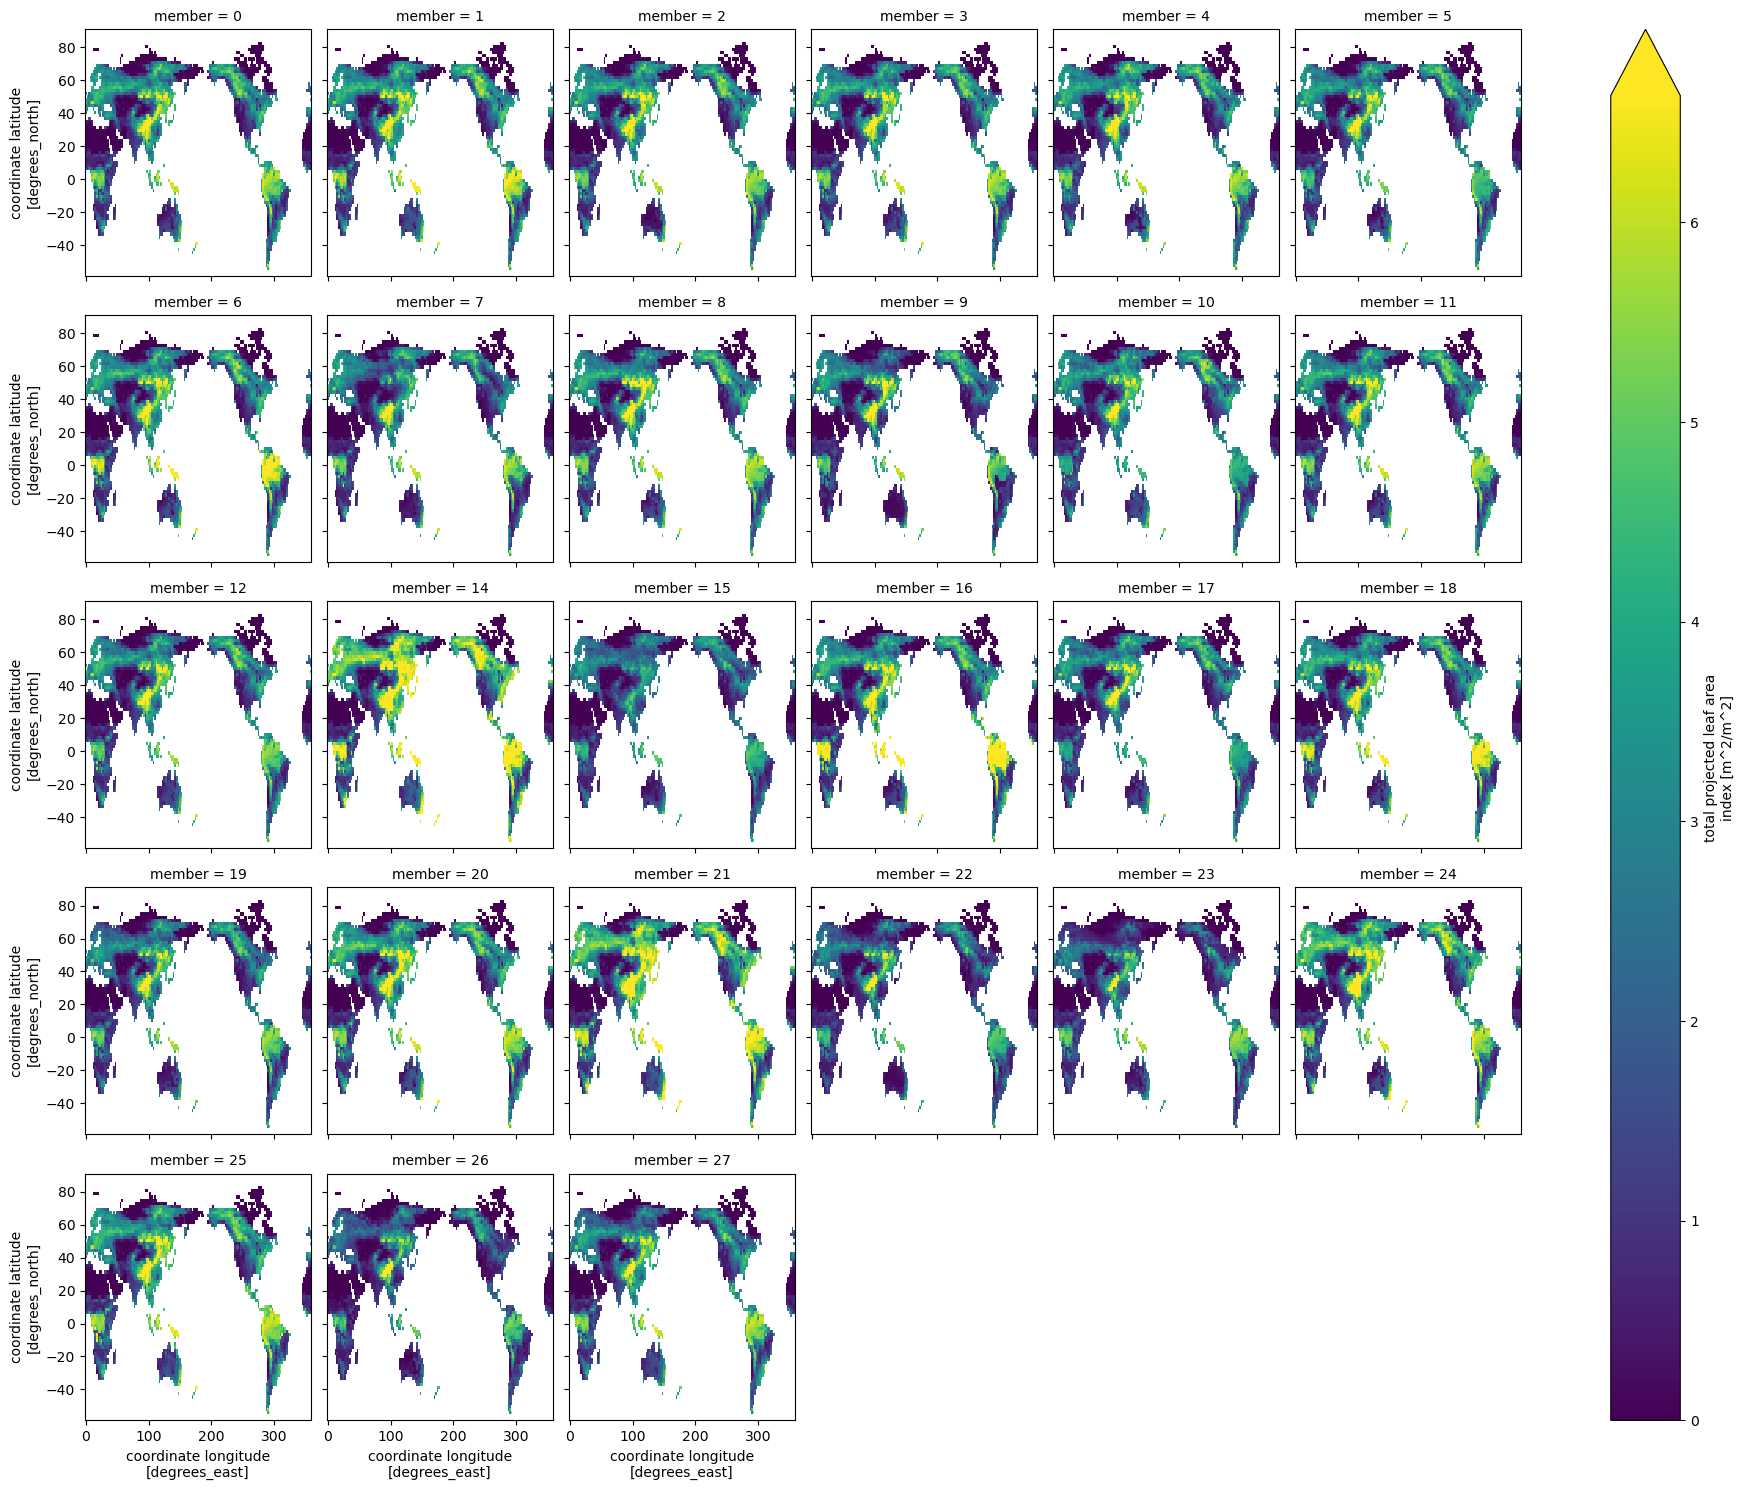

In [ ]:
# fppe_lai_max.plot(col="member", col_wrap=6, robust=True)

# Annual mean

In [ ]:
# ------------------------------------------------------------------
# Subset time and compute the annual mean --> use this onwards
# ------------------------------------------------------------------
print("Computing annual mean and persisting")

fppe_ann = {}
for v, da in fppe.items():
    if "time" in da.dims:
        fppe_ann[v] = compute_annual_mean(da.sel(time=FPPE_SETTINGS["TIME_SLICE"])).persist()

cmip_ann = {}
for sid, vardict in cmip.items():
    cmip_ann[sid] = {}
    for v, da in vardict.items():
        if "time" in da.dims:
            cmip_ann[sid][v] = compute_annual_mean(da.sel(time=CMIP_SETTINGS["TIME_SLICE"])).persist()

Computing annual mean and persisting


# Time mean

In [ ]:
# ------------------------------------------------------------------
# Compute the time mean
# ------------------------------------------------------------------
print("Computing annual mean and persisting")

fppe_tm = {}
for v, da in fppe_ann.items():
    fppe_tm[v] = da.mean(dim="year").where(fppe_mask).compute()

cmip_tm = {}
for sid, vardict in cmip_ann.items():
    cmip_tm[sid] = {}
    for v, da in vardict.items():
        cmip_tm[sid][v] = da.mean(dim="year").where(cmip[sid]["mask"]).compute()

Computing annual mean and persisting


# Maximum climatological LAI
(ideally the growing season)

In [ ]:
fppe_ann_max = {"TLAI_month_1": fppe["TLAI_month_1"].groupby("time.year").max().compute()}
fppe_clim_max = {"TLAI_month_1": fppe["TLAI_month_1"].groupby("time.month").mean().max(dim="month").compute()}

cmip_ann_max = {}
cmip_clim_max = {}
for sid, vardict in cmip.items():
    cmip_ann_max[sid] = {"lai": vardict["lai"].groupby("time.year").max().compute()}
    cmip_clim_max[sid] = {"lai": vardict["lai"].groupby("time.month").mean().max(dim="month").compute()}

# Aridity (dryness) index

## Correct computation

In [ ]:
fppe_tm["RN_month_1"] = fppe_tm["FSNS_month_1"] - fppe_tm["FLNS_month_1"]
fppe_tm["AI_month_1"] = compute_aridity_index(fppe_tm["PRECT_month_1"], fppe_tm["RN_month_1"]).where(fppe_mask)

for sid, vardict in cmip_tm.items():
    cmip_tm[sid]["rn"] = vardict["rlds"] + vardict["rsds"] - vardict["rlus"] - vardict["rsus"]
    cmip_tm[sid]["ai"] = compute_aridity_index(vardict["pr"], vardict["rn"]).where(cmip[sid]["mask"] == 1)

## Wrong computation (bug from earlier)

In [50]:
fppe_rn = fppe_tm["FSNS_month_1"] - fppe_tm["FLNS_month_1"]
fppe_rn_bug = fppe_tm["FSNS_month_1"] + fppe_tm["FLNS_month_1"]
fppe_sfc_balance = fppe_tm["FSNS_month_1"] - fppe_tm["FLNS_month_1"] - fppe_tm["EFLX_LH_TOT_month_1"] - fppe_tm["FSH_month_1"]

fppe_ai = compute_aridity_index(fppe_tm["PRECT_month_1"], fppe_rn)
fppe_ai_bug = compute_aridity_index(fppe_tm["PRECT_month_1"], fppe_rn_bug)

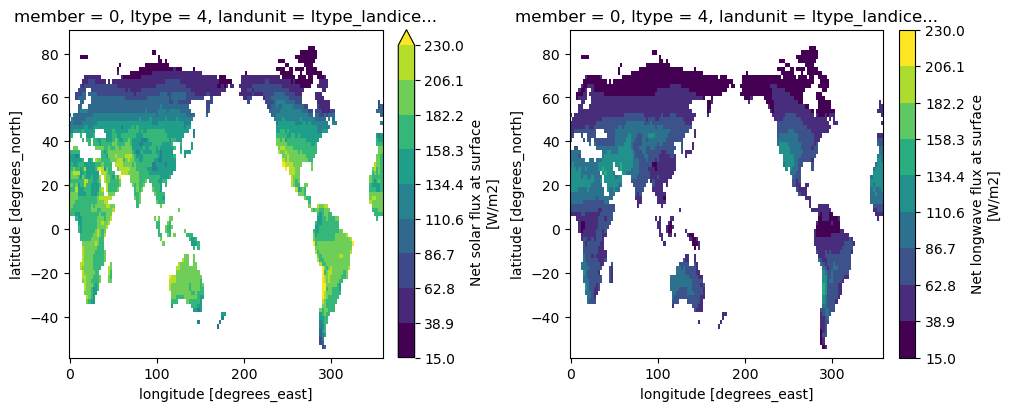

In [51]:
m = 0

fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
fppe_tm["FSNS_month_1"].sel(member=m).plot(ax=axs[0], levels=10, vmin=15, vmax=230)
fppe_tm["FLNS_month_1"].sel(member=m).plot(ax=axs[1], levels=10, vmin=15, vmax=230)

Text(0.5, 1.0, 'bug: $R_n/P$')

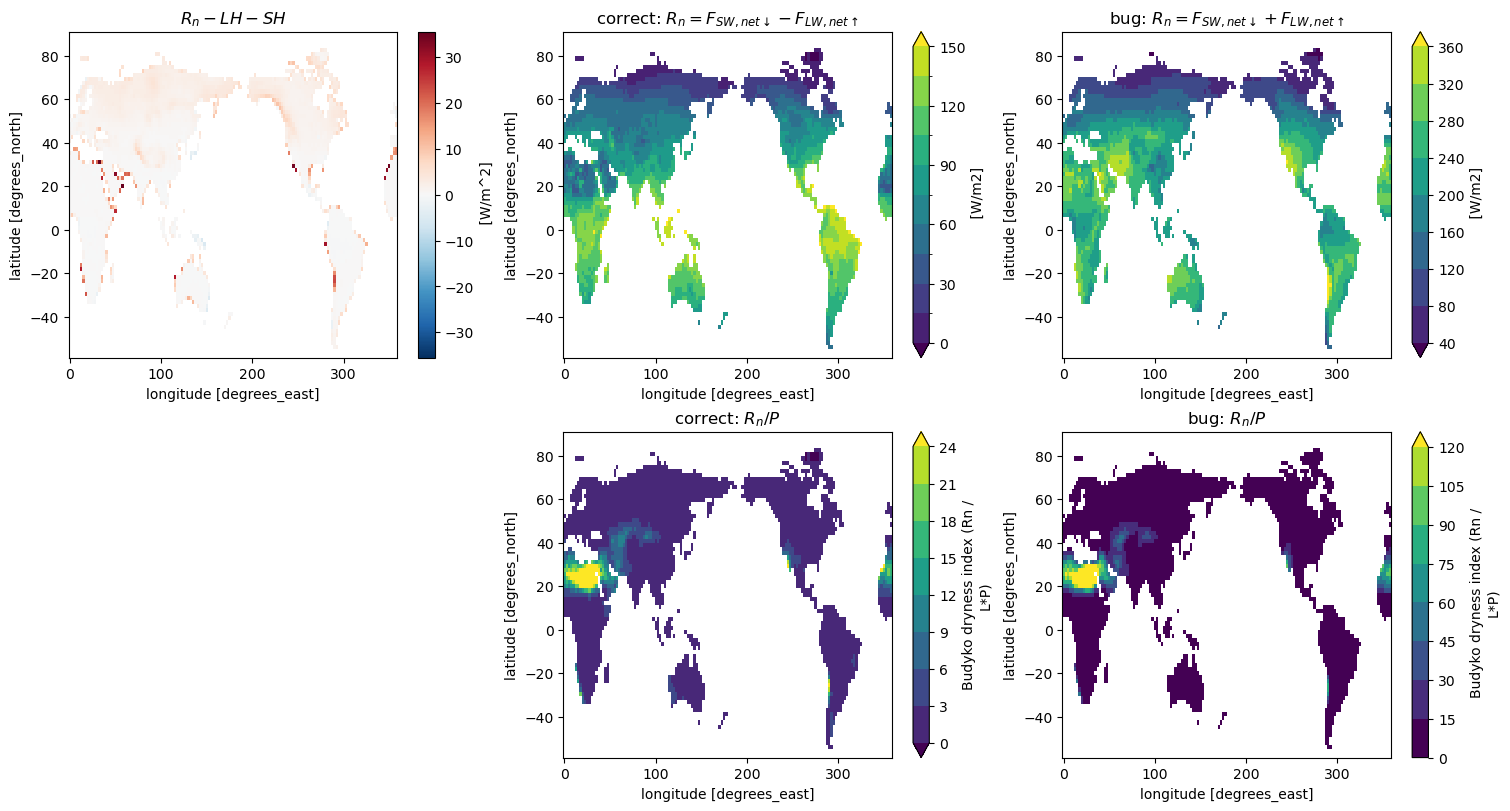

In [52]:
m = 0

fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout="constrained")
axs = axes.ravel()

fppe_sfc_balance.sel(member=m).plot(ax=axs[0])
fppe_rn.sel(member=m).plot(ax=axs[1], levels=10, robust=True)
fppe_rn_bug.sel(member=m).plot(ax=axs[2], levels=10, robust=True)

fppe_ai.sel(member=m).plot(ax=axs[4], levels=10, robust=True)
fppe_ai_bug.sel(member=m).plot(ax=axs[5], levels=10, robust=True)

axs[0].set_title("$R_n-LH-SH$")
axs[1].set_title("correct: $R_n = F_{SW,net\\downarrow} - F_{LW,net\\uparrow}$")
axs[2].set_title("bug: $R_n = F_{SW,net\\downarrow} + F_{LW,net\\uparrow}$")
axs[3].remove()
axs[4].set_title("correct: $R_n/P$")
axs[5].set_title("bug: $R_n/P$")

Text(0.5, 1.0, 'bug: $R_n = F_{SW,net\\downarrow} + F_{LW,net\\uparrow}$')

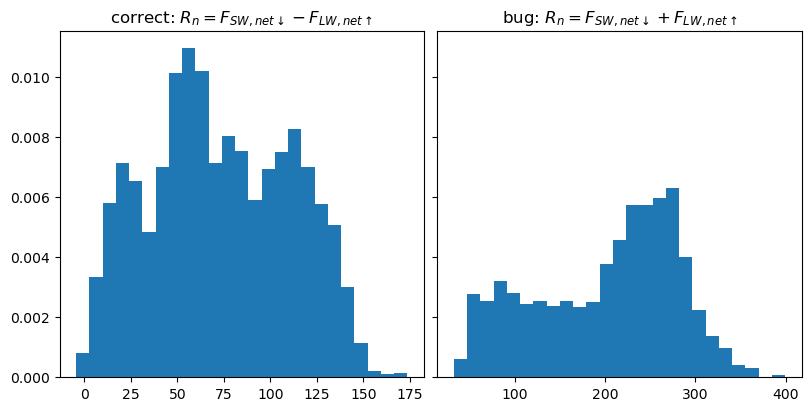

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout="constrained")
axs[0].hist(fppe_rn.values.ravel(), bins=25, density=True);
axs[1].hist(fppe_rn_bug.values.ravel(), bins=25, density=True);

axs[0].set_title("correct: $R_n = F_{SW,net\\downarrow} - F_{LW,net\\uparrow}$")
axs[1].set_title("bug: $R_n = F_{SW,net\\downarrow} + F_{LW,net\\uparrow}$")

Text(0.5, 1.0, 'bug')

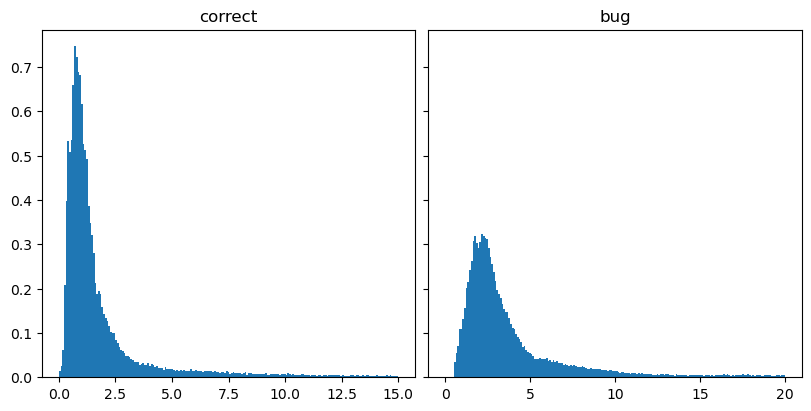

In [56]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout="constrained")
axs[0].hist(fppe_ai.values.ravel(), bins=np.linspace(0, 15, 200), density=True);
axs[1].hist(fppe_ai_bug.values.ravel(), bins=np.linspace(0, 20, 200), density=True);

axs[0].set_title("correct")
axs[1].set_title("bug")

In [ ]:
# fppe_tm["RN_month_1"] = fppe_tm["FSNS_month_1"] + fppe_tm["FLNS_month_1"]
# fppe_tm["AI_month_1"] = compute_aridity_index(fppe_tm["PRECT_month_1"], fppe_tm["RN_month_1"]).where(fppe_mask)

# for sid, vardict in cmip_tm.items():
#     cmip_tm[sid]["rn"] = vardict["rlds"] + vardict["rsds"] + vardict["rlus"] + vardict["rsus"]
#     cmip_tm[sid]["ai"] = compute_aridity_index(vardict["pr"], vardict["rn"]).where(cmip[sid]["mask"] == 1)

# Pooled quantile bin edges

## CMIP6, y-bin, LAI

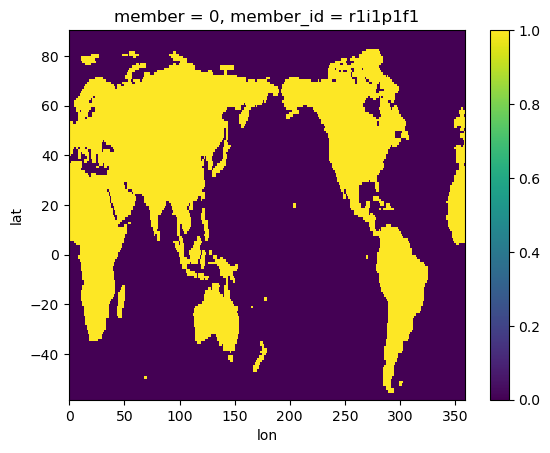

In [ ]:
(cmip["CESM2"]["mask"] == 1).plot()


mon

=== ACCESS-ESM1-5 ===
lai: ('time', 'lat', 'lon') (240, 119, 192) -> 5.484e+06 [0.000e+00, 6.783e+00] zeros=2.105e+05 (3.838%)
=== AWI-ESM-1-1-LR ===
lai: ('time', 'lat', 'lon') (240, 79, 192) -> 3.640e+06 [0.000e+00, 6.116e+00] zeros=2.074e+04 (0.570%)
=== CESM2 ===
lai: ('time', 'lat', 'lon') (240, 158, 288) -> 1.092e+07 [0.000e+00, 1.374e+01] zeros=4.402e+05 (4.031%)
=== CESM2-FV2 ===
lai: ('time', 'lat', 'lon') (240, 79, 144) -> 2.730e+06 [0.000e+00, 1.280e+01] zeros=1.157e+05 (4.237%)
=== CESM2-WACCM ===
lai: ('time', 'lat', 'lon') (240, 158, 288) -> 1.092e+07 [0.000e+00, 1.360e+01] zeros=4.458e+05 (4.082%)
=== CMCC-CM2-SR5 ===
lai: ('time', 'lat', 'lon') (240, 158, 288) -> 1.092e+07 [0.000e+00, 2.095e+01] zeros=3.959e+05 (3.625%)
=== CMCC-ESM2 ===
lai: ('time', 'lat', 'lon') (240, 158, 288) -> 1.092e+07 [0.000e+00, 2.061e+01] zeros=3.994e+05 (3.657%)
=== CNRM-CM6-1 ===
lai: ('time', 'lat', 'lon') (240, 105, 256) -> 6.451e+06 [0.000e+00, 6.004e+00] zeros=9.600e+04 (1.488%)
=

/glade/work/bbuchovecky/et_unc/proc/qbin_edges/cmip6.lai_clim.15_quantiles_pooled.199501-201412.nc
/glade/work/bbuchovecky/et_unc/proc/qbin_edges/cmip6.lai_clim.15_quantiles_pooled.199501-201412.png

year_max

=== ACCESS-ESM1-5 ===
lai: ('year', 'lat', 'lon') (20, 119, 192) -> 4.570e+05 [0.000e+00, 6.783e+00] zeros=1.754e+04 (3.838%)
=== AWI-ESM-1-1-LR ===
lai: ('year', 'lat', 'lon') (20, 79, 192) -> 3.034e+05 [0.000e+00, 6.116e+00] zeros=1.288e+03 (0.425%)
=== CESM2 ===
lai: ('year', 'lat', 'lon') (20, 158, 288) -> 9.101e+05 [0.000e+00, 1.374e+01] zeros=3.333e+04 (3.663%)
=== CESM2-FV2 ===
lai: ('year', 'lat', 'lon') (20, 79, 144) -> 2.275e+05 [0.000e+00, 1.280e+01] zeros=9.023e+03 (3.966%)
=== CESM2-WACCM ===
lai: ('year', 'lat', 'lon') (20, 158, 288) -> 9.101e+05 [0.000e+00, 1.360e+01] zeros=3.379e+04 (3.712%)
=== CMCC-CM2-SR5 ===
lai: ('year', 'lat', 'lon') (20, 158, 288) -> 9.101e+05 [0.000e+00, 2.095e+01] zeros=2.448e+04 (2.690%)
=== CMCC-ESM2 ===
lai: ('year', 'lat', 'lon') (20,

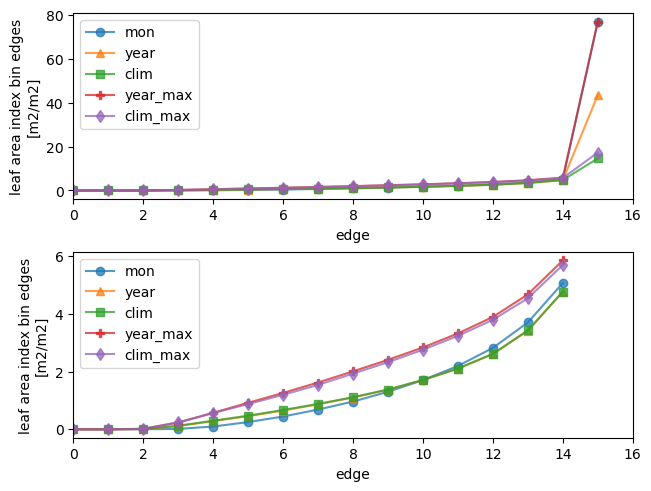

In [ ]:
cmip_y_bin_edges = {}

for aggr, data in zip(["mon", "year", "clim", "year_max", "clim_max"], [cmip, cmip_ann, cmip_tm, cmip_ann_max, cmip_clim_max]):
    print(f"\n{aggr}\n")

    lai_flat_list = []
    for sid in data.keys():
        print(f"=== {sid} ===")
        lai = _safe_squeeze(data[sid]["lai"], dim="member", drop=True)
        lai_flat = lai.where(cmip[sid]["mask"] == 1).values.ravel()
        lai_flat_list.append(lai_flat[~np.isnan(lai_flat)])
        print(
            f"lai: {lai.dims} {lai.shape} -> {len(lai_flat):.3e} "
            f"[{np.nanmin(lai_flat):0.3e}, {np.nanmax(lai_flat):0.3e}] "
            f"zeros={np.nansum(lai_flat == 0):.3e} "
            f"({np.nansum(lai_flat == 0) / len(lai_flat) * 100:0.3f}%)"
        )
        if (np.nansum(lai_flat == 0) / len(lai_flat)) > 0.10:
            warnings.warn(f"Warning: {np.nansum(lai_flat == 0) / len(lai_flat) * 100:0.3f} > 10%")  

    lai_flat_all = np.concatenate(lai_flat_list)
    plt.hist(lai_flat_all, density=True)
    plt.title(aggr)

    print(
        f"== concat ==\n"
        f"lai_flat_all: {len(lai_flat_all)} "
        f"[{np.nanmin(lai_flat_all):0.3e}, {np.nanmax(lai_flat_all):0.3e}]"
    )

    y_edges = _build_edges(
        arr_flat=lai_flat_all,
        n_bins=N_YBINS,
        strategy="quantile",
        value_range=None,
        collapse_duplicates=False
    )

    n_y_eff = len(y_edges) - 1

    print(f"y_edges ({n_y_eff}): {y_edges}")

    y_edges_da = xr.DataArray(
        data=y_edges,
        dims=["edge"],
        coords=dict(edge=np.arange(n_y_eff+1)),
        name="lai",
        attrs={
            "long_name"       : "leaf area index bin edges",
            "units"           : "m2/m2",
            "variable"        : "leaf area index",
            "strategy"        : "quantile",
            "n_bins"          : n_y_eff,
            "n_bins_requested": N_YBINS,
            "collapse_duplicate_quantile_bins": 0,
            "pool_edges"      : 1,
            "source_id"       : list(data.keys()),
            "time_period"     : cmip_time_str,
        },
    )
    fstem = f"cmip6.lai_{aggr}.{N_YBINS}_quantiles_pooled.{cmip_time_str}"
    y_edges_da.to_netcdf(BIN_EDGES_ROOT / f"{fstem}.nc")
    print(BIN_EDGES_ROOT / f"{fstem}.nc")
    plot_edges(y_edges_da, BIN_EDGES_ROOT / f"{fstem}.png")
    print(BIN_EDGES_ROOT / f"{fstem}.png")

    cmip_y_bin_edges[aggr] = y_edges_da


# Plot different LAI bin edges
fig, axs = plt.subplots(2, 1, layout="constrained")

cmip_y_bin_edges["mon"].plot(ax=axs[0], alpha=0.75, marker="o", label="mon")
cmip_y_bin_edges["year"].plot(ax=axs[0], alpha=0.75, marker="^", label="year")
cmip_y_bin_edges["clim"].plot(ax=axs[0], alpha=0.75, marker="s", label="clim")
cmip_y_bin_edges["year_max"].plot(ax=axs[0], alpha=0.75, marker="P", label="year_max")
cmip_y_bin_edges["clim_max"].plot(ax=axs[0], alpha=0.75, marker="d", label="clim_max")

cmip_y_bin_edges["mon"][:-1].plot(ax=axs[1],marker="o", alpha=0.75, label="mon")
cmip_y_bin_edges["year"][:-1].plot(ax=axs[1],marker="^", alpha=0.75, label="year")
cmip_y_bin_edges["clim"][:-1].plot(ax=axs[1],marker="s", alpha=0.75, label="clim")
cmip_y_bin_edges["year_max"][:-1].plot(ax=axs[1], alpha=0.75, marker="P", label="year_max")
cmip_y_bin_edges["clim_max"][:-1].plot(ax=axs[1], alpha=0.75, marker="d", label="clim_max")

for ax in axs:
    ax.legend()
    ax.set_xlim(0, len(cmip_y_bin_edges["mon"]))

fstem = f"cmip6.lai_compare.{N_YBINS}_quantiles_pooled.{cmip_time_str}"
fig.savefig(BIN_EDGES_ROOT / f"{fstem}.png", dpi=120, bbox_inches="tight")
print(BIN_EDGES_ROOT / f"{fstem}.png")

## CMIP6, x-bin, aridity

In [ ]:
cmip_x_bin_edges = {}

ai_flat_list = []
for sid in cmip_tm.keys():
    print(f"=== {sid} ===")
    ai = _safe_squeeze(cmip_tm[sid]["ai"], dim="member", drop=True)
    ai_flat = ai.where(~np.isnan(cmip[sid]["mask"])).values.ravel()
    ai_flat_list.append(ai_flat[~np.isnan(ai_flat)])
    print(
        f"aridity: {ai.dims} {ai.shape} -> {len(ai_flat):.3e} "
        f"[{np.nanmin(ai_flat):0.3e}, {np.nanmax(ai_flat):0.3e}] "
        f"zeros={np.nansum(ai_flat == 0):.3e} "
        f"({np.nansum(ai_flat == 0) / len(ai_flat) * 100:0.3f}%)"
    )
    if (np.nansum(ai_flat == 0) / len(ai_flat)) > 0.10:
        warnings.warn(f"Warning: {np.nansum(ai_flat == 0) / len(ai_flat) * 100:0.3f} > 10%")  

ai_flat_all = np.concatenate(ai_flat_list)
print(
    f"== concat ==\n"
    f"ai_flat_all: {len(ai_flat_all)} "
    f"[{np.nanmin(ai_flat_all):0.3e}, {np.nanmax(ai_flat_all):0.3e}]"
)
plt.hist(ai_flat_all)
plt.title("clim")

x_edges = _build_edges(
    arr_flat=ai_flat_all,
    n_bins=N_XBINS,
    strategy="quantile",
    value_range=None,
    collapse_duplicates=False
)

n_x_eff = len(x_edges) - 1

print(f"x_edges ({n_x_eff}): {x_edges}")

x_edges_da = xr.DataArray(
    data=x_edges,
    dims=["edge"],
    coords=dict(edge=np.arange(n_x_eff+1)),
    name="aridity",
    attrs={
        "long_name"       : "aridity index bin edges",
        "units"           : "1",
        "variable"        : "aridity index (Rn/P)",
        "strategy"        : "quantile",
        "n_bins"          : n_x_eff,
        "n_bins_requested": N_XBINS,
        "collapse_duplicate_quantile_bins": 0,
        "pool_edges"      : 1,
        "source_id"       : list(data.keys()),
        "time_period"     : cmip_time_str,
    },
)
# fstem = f"cmip6.ai_clim.{N_XBINS}_quantiles_pooled.{cmip_time_str}"
fstem = f"cmip6.ai_clim.rn_bug.{N_XBINS}_quantiles_pooled.{cmip_time_str}"
x_edges_da.to_netcdf(BIN_EDGES_ROOT / f"{fstem}.nc")
print(BIN_EDGES_ROOT / f"{fstem}.nc")
plot_edges(x_edges_da, BIN_EDGES_ROOT / f"{fstem}.png")
print(BIN_EDGES_ROOT / f"{fstem}.png")

cmip_x_bin_edges["clim"] = x_edges_da

=== ACCESS-ESM1-5 ===
aridity: ('lat', 'lon') (119, 192) -> 2.285e+04 [-7.517e-01, 7.918e+01] zeros=0.000e+00 (0.000%)
=== AWI-ESM-1-1-LR ===
aridity: ('lat', 'lon') (79, 192) -> 1.517e+04 [-1.470e-01, 1.689e+03] zeros=0.000e+00 (0.000%)
=== CESM2 ===
aridity: ('lat', 'lon') (158, 288) -> 4.550e+04 [-5.132e-01, 6.138e+01] zeros=0.000e+00 (0.000%)
=== CESM2-FV2 ===
aridity: ('lat', 'lon') (79, 144) -> 1.138e+04 [-2.108e-01, 5.127e+01] zeros=0.000e+00 (0.000%)
=== CESM2-WACCM ===
aridity: ('lat', 'lon') (158, 288) -> 4.550e+04 [-5.525e-01, 1.134e+02] zeros=0.000e+00 (0.000%)
=== CMCC-CM2-SR5 ===
aridity: ('lat', 'lon') (158, 288) -> 4.550e+04 [-1.216e-01, 1.441e+02] zeros=0.000e+00 (0.000%)
=== CMCC-ESM2 ===
aridity: ('lat', 'lon') (158, 288) -> 4.550e+04 [-2.219e-01, 1.418e+02] zeros=0.000e+00 (0.000%)
=== CNRM-CM6-1 ===
aridity: ('lat', 'lon') (105, 256) -> 2.688e+04 [-2.073e-01, 3.609e+02] zeros=0.000e+00 (0.000%)
=== CNRM-ESM2-1 ===
aridity: ('lat', 'lon') (105, 256) -> 2.688e+04 [-1

## FPPE, y-bin, LAI


mon
lai: ('member', 'time', 'lat', 'lon') (27, 240, 79, 144) -> 7.372e+07 [0.000e+00, 1.634e+01] zeros=1.708e+06 (2.316%)
y_edges (15): [0.00000000e+00 0.00000000e+00 4.79414021e-05 3.88399526e-03
 3.19657053e-02 1.52758370e-01 3.53633714e-01 5.96800486e-01
 8.86932278e-01 1.24547546e+00 1.68854586e+00 2.21698511e+00
 2.84714847e+00 3.63596562e+00 4.75572735e+00 1.63401489e+01]
/glade/work/bbuchovecky/et_unc/proc/qbin_edges/fppe.lai_mon.15_quantiles_pooled.199501-201412.nc
/glade/work/bbuchovecky/et_unc/proc/qbin_edges/fppe.lai_mon.15_quantiles_pooled.199501-201412.png

year
lai: ('member', 'year', 'lat', 'lon') (27, 20, 79, 144) -> 6.143e+06 [0.000e+00, 1.017e+01] zeros=1.249e+05 (2.034%)
y_edges (15): [0.00000000e+00 0.00000000e+00 1.02382722e-03 6.48132266e-02
 2.66898038e-01 4.40727281e-01 6.30664588e-01 8.36803989e-01
 1.06907871e+00 1.35572386e+00 1.70601204e+00 2.11074070e+00
 2.61141613e+00 3.26761651e+00 4.37562692e+00 1.01688627e+01]
/glade/work/bbuchovecky/et_unc/proc/qbin_

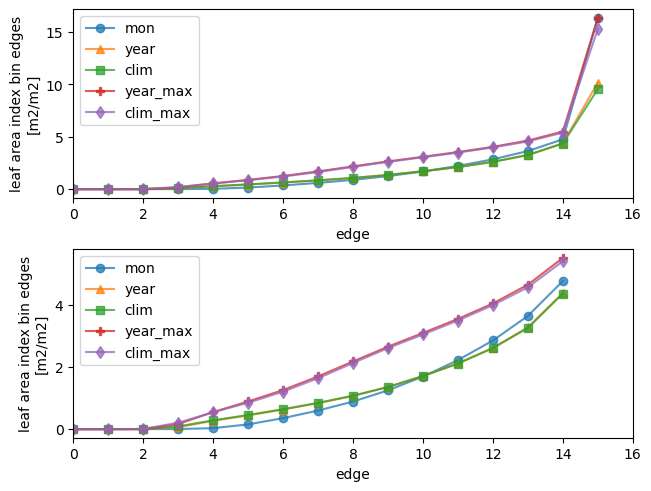

In [ ]:
fppe_y_bin_edges = {}

for aggr, data in zip(["mon", "year", "clim", "year_max", "clim_max"], [fppe, fppe_ann, fppe_tm, fppe_ann_max, fppe_clim_max]):
    print(f"\n{aggr}")

    lai_flat_all = data["TLAI_month_1"].sel(lat=LAT_BNDS).where(fppe_mask).values.ravel()
    plt.hist(lai_flat_all, density=True)
    plt.title(aggr)
    
    print(
        f"lai: {data['TLAI_month_1'].dims} {data['TLAI_month_1'].shape} -> {len(lai_flat_all):.3e} "
        f"[{np.nanmin(lai_flat_all):0.3e}, {np.nanmax(lai_flat_all):0.3e}] "
        f"zeros={np.nansum(lai_flat_all == 0):.3e} "
        f"({np.nansum(lai_flat_all == 0) / len(lai_flat_all) * 100:0.3f}%)"
    )

    y_edges = _build_edges(
        arr_flat=lai_flat_all,
        n_bins=N_YBINS,
        strategy="quantile",
        value_range=None,
        collapse_duplicates=False
    )

    n_y_eff = len(y_edges) - 1

    print(f"y_edges ({n_y_eff}): {y_edges}")

    y_edges_da = xr.DataArray(
        data=y_edges,
        dims=["edge"],
        coords=dict(edge=np.arange(n_y_eff+1)),
        name="lai",
        attrs={
            "long_name"       : "leaf area index bin edges",
            "units"           : "m2/m2",
            "variable"        : "leaf area index",
            "strategy"        : "quantile",
            "n_bins"          : n_y_eff,
            "n_bins_requested": N_YBINS,
            "collapse_duplicate_quantile_bins": 0,
            "pool_edges"      : 1,
            "time_period"     : fppe_time_str,
        },
    )
    fstem = f"fppe.lai_{aggr}.{N_YBINS}_quantiles_pooled.{fppe_time_str}"
    y_edges_da.to_netcdf(BIN_EDGES_ROOT / f"{fstem}.nc")
    print(BIN_EDGES_ROOT / f"{fstem}.nc")
    plot_edges(y_edges_da, BIN_EDGES_ROOT / f"{fstem}.png")
    print(BIN_EDGES_ROOT / f"{fstem}.png")

    fppe_y_bin_edges[aggr] = y_edges_da


# Plot different LAI bin edges
fig, axs = plt.subplots(2, 1, layout="constrained")

fppe_y_bin_edges["mon"].plot(ax=axs[0], alpha=0.75, marker="o", label="mon")
fppe_y_bin_edges["year"].plot(ax=axs[0], alpha=0.75, marker="^", label="year")
fppe_y_bin_edges["clim"].plot(ax=axs[0], alpha=0.75, marker="s", label="clim")
fppe_y_bin_edges["year_max"].plot(ax=axs[0], alpha=0.75, marker="P", label="year_max")
fppe_y_bin_edges["clim_max"].plot(ax=axs[0], alpha=0.75, marker="d", label="clim_max")

fppe_y_bin_edges["mon"][:-1].plot(ax=axs[1], marker="o", alpha=0.75, label="mon")
fppe_y_bin_edges["year"][:-1].plot(ax=axs[1], marker="^", alpha=0.75, label="year")
fppe_y_bin_edges["clim"][:-1].plot(ax=axs[1], marker="s", alpha=0.75, label="clim")
fppe_y_bin_edges["year_max"][:-1].plot(ax=axs[1], alpha=0.75, marker="P", label="year_max")
fppe_y_bin_edges["clim_max"][:-1].plot(ax=axs[1], alpha=0.75, marker="d", label="clim_max")

for ax in axs:
    ax.legend()
    ax.set_xlim(0, len(fppe_y_bin_edges["mon"]))

fstem = f"fppe.lai_compare.{N_YBINS}_quantiles_pooled.{fppe_time_str}"
fig.savefig(BIN_EDGES_ROOT / f"{fstem}.png", dpi=120, bbox_inches="tight")
print(BIN_EDGES_ROOT / f"{fstem}.png")

## FPPE, x-bin, aridity

In [ ]:
fppe_x_bin_edges = {}

ai_flat_all = fppe_tm["AI_month_1"].sel(lat=LAT_BNDS).where(fppe_mask).values.ravel()
plt.hist(ai_flat_all, density=True)
plt.title("clim")

print(
    f"aridity: {fppe_tm['AI_month_1'].dims} {fppe_tm['AI_month_1'].shape} -> {len(ai_flat_all):.3e} "
    f"[{np.nanmin(ai_flat_all):0.3e}, {np.nanmax(ai_flat_all):0.3e}] "
    f"zeros={np.nansum(ai_flat_all == 0):.3e} "
    f"({np.nansum(ai_flat_all == 0) / len(ai_flat_all) * 100:0.3f}%)"
)

x_edges = _build_edges(
    arr_flat=ai_flat_all,
    n_bins=N_XBINS,
    strategy="quantile",
    value_range=None,
    collapse_duplicates=False
)

n_x_eff = len(x_edges) - 1

print(f"x_edges ({n_x_eff}): {x_edges}")

x_edges_da = xr.DataArray(
    data=x_edges,
    dims=["edge"],
    coords=dict(edge=np.arange(n_x_eff+1)),
    name="aridity",
    attrs={
        "long_name"       : "aridity index bin edges",
        "units"           : "1",
        "variable"        : "aridity index (Rn/P)",
        "strategy"        : "quantile",
        "n_bins"          : n_x_eff,
        "n_bins_requested": N_XBINS,
        "collapse_duplicate_quantile_bins": 0,
        "pool_edges"      : 1,
        "time_period"     : fppe_time_str,
    },
)
# fstem = f"fppe.ai_clim.{N_XBINS}_quantiles_pooled.{fppe_time_str}"
fstem = f"fppe.ai_clim.rn_bug.{N_XBINS}_quantiles_pooled.{fppe_time_str}"
x_edges_da.to_netcdf(BIN_EDGES_ROOT / f"{fstem}.nc")
print(BIN_EDGES_ROOT / f"{fstem}.nc")
plot_edges(x_edges_da, BIN_EDGES_ROOT / f"{fstem}.png")
print(BIN_EDGES_ROOT / f"{fstem}.png")

fppe_x_bin_edges["clim"] = x_edges_da

aridity: ('member', 'lat', 'lon') (27, 79, 144) -> 3.072e+05 [-2.761e-01, 1.440e+02] zeros=0.000e+00 (0.000%)
x_edges (15): [ -0.27610414   0.40288072   0.53578443   0.65566364   0.74992868
   0.84600961   0.94740671   1.05739538   1.19155148   1.34513011
   1.55879035   1.91058741   2.4871869    4.0361571    8.97134016
 144.0129857 ]
/glade/work/bbuchovecky/et_unc/proc/qbin_edges/fppe.ai_clim.15_quantiles_pooled.199501-201412.nc
/glade/work/bbuchovecky/et_unc/proc/qbin_edges/fppe.ai_clim.15_quantiles_pooled.199501-201412.png


## Compare

Text(0.5, 1.0, 'monthly LAI')

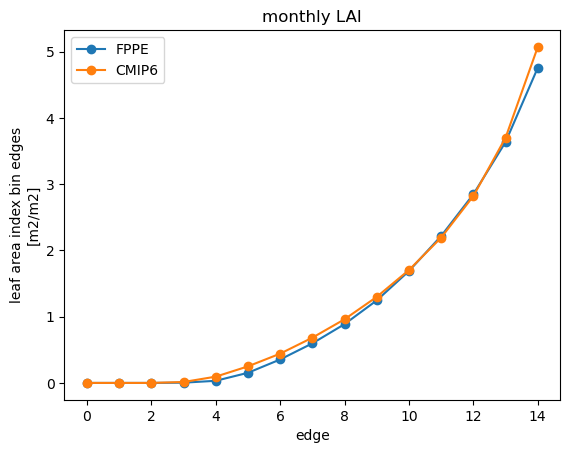

In [ ]:
fppe_y_bin_edges["mon"][:-1].plot(marker="o", label="FPPE")
cmip_y_bin_edges["mon"][:-1].plot(marker="o", label="CMIP6")
plt.legend()
plt.title("monthly LAI")

Text(0.5, 1.0, 'annual mean LAI')

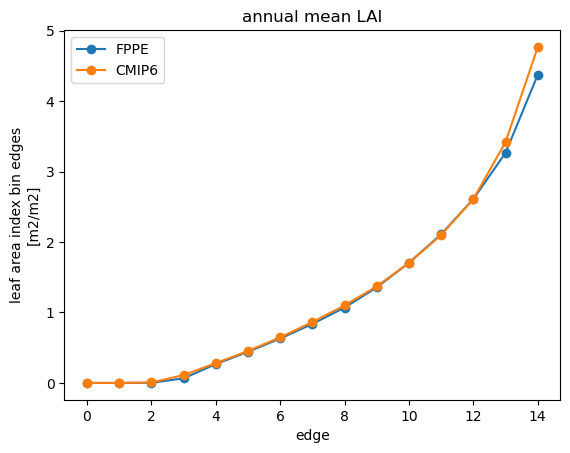

In [ ]:
fppe_y_bin_edges["year"][:-1].plot(marker="o", label="FPPE")
cmip_y_bin_edges["year"][:-1].plot(marker="o", label="CMIP6")
plt.legend()
plt.title("annual mean LAI")

Text(0.5, 1.0, 'climatological LAI')

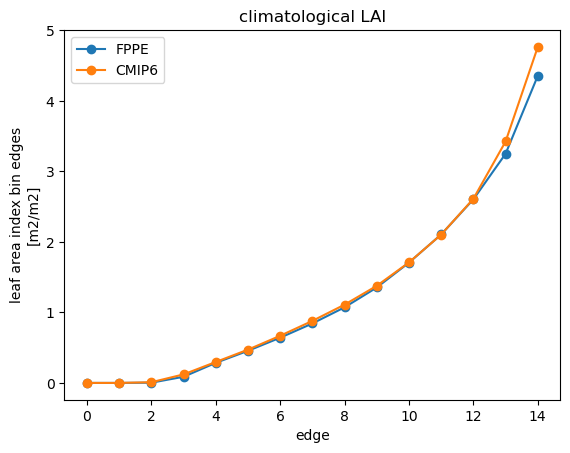

In [ ]:
fppe_y_bin_edges["clim"][:-1].plot(marker="o", label="FPPE")
cmip_y_bin_edges["clim"][:-1].plot(marker="o", label="CMIP6")
plt.legend()
plt.title("climatological LAI")

Text(0.5, 1.0, 'annual maximum LAI')

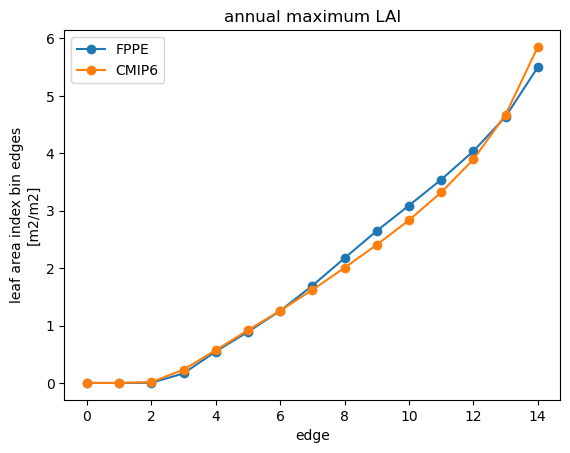

In [ ]:
fppe_y_bin_edges["year_max"][:-1].plot(marker="o", label="FPPE")
cmip_y_bin_edges["year_max"][:-1].plot(marker="o", label="CMIP6")
plt.legend()
plt.title("annual maximum LAI")

Text(0.5, 1.0, 'climatological maximum LAI')

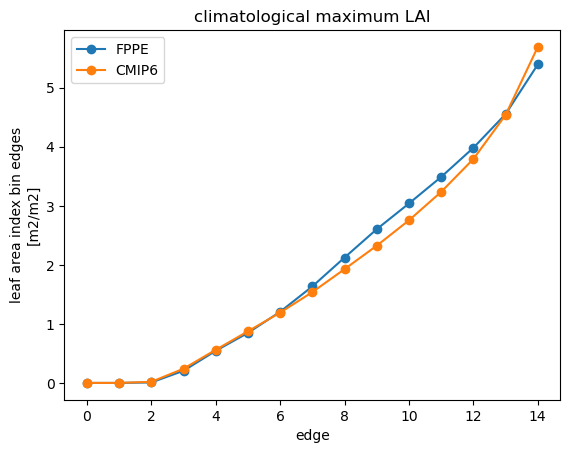

In [ ]:
fppe_y_bin_edges["clim_max"][:-1].plot(marker="o", label="FPPE")
cmip_y_bin_edges["clim_max"][:-1].plot(marker="o", label="CMIP6")
plt.legend()
plt.title("climatological maximum LAI")

Text(0.5, 1.0, 'climatological aridity')

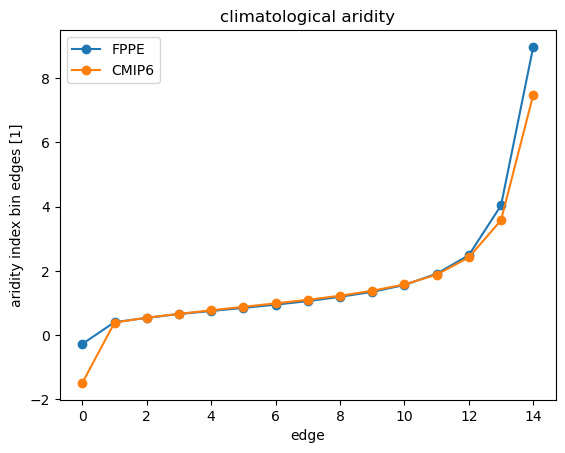

In [ ]:
fppe_x_bin_edges["clim"][:-1].plot(marker="o", label="FPPE")
cmip_x_bin_edges["clim"][:-1].plot(marker="o", label="CMIP6")
plt.legend()
plt.title("climatological aridity")

# Binned mean ET

Use climatological LAI and aridity with annual mean ET.

## CMIP6

In [ ]:
# Plot diagnostic climatological fields
mid = get_one_mid(cmip[sid]["evspsbl"])
for sid in cmip_tm.keys():
    for v in ["lai", "rn", "pr", "ai"]:
        out = FIG_ROOT / "cmip6" / v / f"cmip6.{sid}.{v}.map.{cmip_time_str}.{mid}.png"
        out.parent.mkdir(exist_ok=True, parents=True)
        quick_map(_safe_squeeze(cmip_tm[sid][v], dim="member", drop=True), out, title=f"{sid}, {cmip_time_str}")
        print(out)

/glade/work/bbuchovecky/et_unc/fig/cmip6/lai/cmip6.ACCESS-ESM1-5.lai.map.199501-201412.r1i1p1f1.png
/glade/work/bbuchovecky/et_unc/fig/cmip6/rn/cmip6.ACCESS-ESM1-5.rn.map.199501-201412.r1i1p1f1.png
/glade/work/bbuchovecky/et_unc/fig/cmip6/pr/cmip6.ACCESS-ESM1-5.pr.map.199501-201412.r1i1p1f1.png
/glade/work/bbuchovecky/et_unc/fig/cmip6/ai/cmip6.ACCESS-ESM1-5.ai.map.199501-201412.r1i1p1f1.png
/glade/work/bbuchovecky/et_unc/fig/cmip6/lai/cmip6.AWI-ESM-1-1-LR.lai.map.199501-201412.r1i1p1f1.png
/glade/work/bbuchovecky/et_unc/fig/cmip6/rn/cmip6.AWI-ESM-1-1-LR.rn.map.199501-201412.r1i1p1f1.png
/glade/work/bbuchovecky/et_unc/fig/cmip6/pr/cmip6.AWI-ESM-1-1-LR.pr.map.199501-201412.r1i1p1f1.png
/glade/work/bbuchovecky/et_unc/fig/cmip6/ai/cmip6.AWI-ESM-1-1-LR.ai.map.199501-201412.r1i1p1f1.png
/glade/work/bbuchovecky/et_unc/fig/cmip6/lai/cmip6.CESM2.lai.map.199501-201412.r1i1p1f1.png
/glade/work/bbuchovecky/et_unc/fig/cmip6/rn/cmip6.CESM2.rn.map.199501-201412.r1i1p1f1.png
/glade/work/bbuchovecky/et

In [ ]:
cmip_bs = []

for sid in sorted(cmip_ann.keys()):
    print(f"\n=== {sid} ===")
    target = _safe_squeeze(cmip_ann[sid]["evspsbl"].where(cmip[sid]["mask"]==1), dim="member", drop=True)
    y_var = _safe_squeeze(cmip_tm[sid]["lai"].where(cmip[sid]["mask"]==1), dim="member", drop=True)
    x_var = _safe_squeeze(cmip_tm[sid]["ai"].where(cmip[sid]["mask"]==1), dim="member", drop=True)
    y_edges = cmip_y_bin_edges["clim"].values
    x_edges = cmip_x_bin_edges["clim"].values

    expand_tcoord = None
    if "time" in target.dims:
        expand_tcoord = "time"
    elif "year" in target.dims:
        expand_tcoord = "year"
    else:
        warnings.warn("Warning: expected 'time' or 'year' in target")

    if (y_var.shape != target.shape):
        print(f"y_var: {y_var.dims} {y_var.shape}  target: {target.dims} {target.shape}")
        if expand_tcoord not in y_var.coords:
            old_shape = y_var.shape
            y_var = y_var.expand_dims({expand_tcoord: target[expand_tcoord]})
            print(f"Expanding {expand_tcoord} dimension of y-bin: {old_shape} -> {y_var.shape}")
        else:
            print(f"{expand_tcoord} in y_var.coords {list(y_var.coords)}, skipping {sid}")
            continue

    if (x_var.shape != target.shape):
        print(f"x_var: {x_var.shape}  target: {target.shape}")
        if expand_tcoord not in x_var.coords:
            old_shape = x_var.shape
            x_var = x_var.expand_dims({expand_tcoord: target[expand_tcoord]})
            print(f"Expanding {expand_tcoord} dimension of x-bin: {old_shape} -> {x_var.shape}")
        else:
            print(f"{expand_tcoord} in x_var.coords {list(x_var.coords)}, skipping {sid}")
            continue
    
    print(f"target: {target.dims} {target.shape} lat=[{target.lat.min().item()}, {target.lat.max().item()}]")
    print(f"y_var: {y_var.dims} {y_var.shape} lat=[{y_var.lat.min().item()}, {y_var.lat.max().item()}]")
    print(f"x_var: {x_var.dims} {x_var.shape} lat=[{x_var.lat.min().item()}, {x_var.lat.max().item()}]")

    def _np(da):
        return da.compute().values if hasattr(da.data, "compute") else da.values

    tgt_np = _np(target)
    y_np   = _np(y_var)
    x_np   = _np(x_var)

    print(f"target_np: {tgt_np.shape}")
    print(f"y_var_np: {y_np.shape}")
    print(f"x_var_np: {x_np.shape}")

    result_np = _bin_stats_single_member(
        tgt_np.ravel(),
        y_np.ravel(),
        x_np.ravel(),
        y_edges, x_edges,
    )

    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

    # Human-readable quantile labels (used when strategy=="quantile")
    def _quantile_labels(n):
        lo = np.linspace(0, 100, n + 1)[:-1]
        hi = np.linspace(0, 100, n + 1)[1:]
        return [f"Q{a:.0f}-Q{b:.0f}" for a, b in zip(lo, hi)]

    y_name = y_var.name or "y_var"
    x_name = x_var.name or "x_var"

    coords = {
        "stats": np.array(["mean", "var_pop", "var_samp", "count"]),
        f"{y_name}_bin_center": ("y_bin", y_centers.data),
        f"{x_name}_bin_center": ("x_bin", x_centers.data),
    }
    coords[f"{y_name}_bin_label"] = ("y_bin", _quantile_labels(n_y_eff))
    coords[f"{x_name}_bin_label"] = ("x_bin", _quantile_labels(n_x_eff))

    bin_stats = xr.DataArray(
        result_np,
        name="evspsbl",
        dims=("stats", "y_bin", "x_bin"),
        coords=coords,
        attrs={
            "long_name"            : f"2-D bin-mean {target.name or 'variable'}",
            "units"                : target.attrs.get("units", "unknown"),
            "y_variable"           : y_name,
            "x_variable"           : x_name,
            "y_strategy"           : "quantile",
            "x_strategy"           : "quantile",
            "y_bin_edges"          : y_edges,
            "x_bin_edges"          : x_edges,
            "n_y_bins"             : n_y_eff,
            "n_x_bins"             : n_x_eff,
            "n_y_bins_requested"   : N_YBINS,
            "n_x_bins_requested"   : N_XBINS,
            "collapse_duplicate_quantile_bins": 0,
            "pool_edges"           : 1,
            "source_id"            : sid,
            "time_period"          : cmip_time_str,
        },
    )

    mid = get_one_mid(cmip[sid]["evspsbl"])
    out = PROC_ROOTS["cmip"] / "qbin" / f"cmip6.{sid}.evspsbl.qbin_clim_pooled.rn_bug.{cmip_time_str}.{mid}.nc"
    out.parent.mkdir(exist_ok=True, parents=True)
    bin_stats.to_netcdf(out)
    print(out)

    cmip_bs.append(bin_stats)

nsid = len(cmip_bs)
sids = sorted(cmip_ann.keys())
cmip_bs = xr.concat(cmip_bs, dim="sid").assign_coords(sid=sids)#.assign_coords(sid=np.arange(nsid), source_id=("sid", sids))
out = PROC_ROOTS["cmip"] / "qbin" / f"cmip6.all{nsid}.evspsbl.qbin_clim_pooled_cmip.rn_bug.{cmip_time_str}.onemember.nc"
out.parent.mkdir(exist_ok=True, parents=True)
cmip_bs.to_netcdf(out)
print(out)


=== ACCESS-ESM1-5 ===
y_var: ('lat', 'lon') (119, 192)  target: ('year', 'lat', 'lon') (20, 119, 192)
Expanding year dimension of y-bin: (119, 192) -> (20, 119, 192)
x_var: (119, 192)  target: (20, 119, 192)
Expanding year dimension of x-bin: (119, 192) -> (20, 119, 192)
target: ('year', 'lat', 'lon') (20, 119, 192) lat=[-57.5, 90.0]
y_var: ('year', 'lat', 'lon') (20, 119, 192) lat=[-57.5, 90.0]
x_var: ('year', 'lat', 'lon') (20, 119, 192) lat=[-57.5, 90.0]
target_np: (20, 119, 192)
y_var_np: (20, 119, 192)
x_var_np: (20, 119, 192)
target_flat: all 456960 -> valid 147940 -> dropped 309020
y_flat: all 456960 -> valid 147940 -> dropped 309020
x_flat: all 456960 -> valid 147940 -> dropped 309020
all valid: 147940
/glade/work/bbuchovecky/et_unc/proc/cmip6/qbin/cmip6.ACCESS-ESM1-5.evspsbl.qbin_clim_pooled.199501-201412.r1i1p1f1.nc

=== AWI-ESM-1-1-LR ===
y_var: ('lat', 'lon') (79, 192)  target: ('year', 'lat', 'lon') (20, 79, 192)
Expanding year dimension of y-bin: (79, 192) -> (20, 79, 19

## FPPE

In [ ]:
# fname = f"fppe.EFLX_LH_TOT.qbin_pooled_cmip.tgt-year.xvar-clim.yvar-year.{fppe_time_str}.nc"
fname = f"fppe.EFLX_LH_TOT.qbin_clim_pooled_cmip.rn_bug.{fppe_time_str}.nc"

fppe_bs = []
for mem in fppe_ann["EFLX_LH_TOT_month_1"].member.values:
    print(f"\n=== {int(mem)} ===")

    ## This is what seems to make the most sense:
    target = fppe_ann["EFLX_LH_TOT_month_1"].where(fppe_mask==1).sel(member=mem)
    y_var = fppe_tm["TLAI_month_1"].where(fppe_mask==1).sel(member=mem)
    x_var = fppe_tm["AI_month_1"].where(fppe_mask==1).sel(member=mem)
    x_edges = cmip_x_bin_edges["clim"].values
    y_edges = cmip_y_bin_edges["clim"].values

    ## Weird stuff here
    # target = fppe_ann["EFLX_LH_TOT_month_1"].where(fppe_mask==1).sel(member=mem)
    # y_var = fppe_ann["TLAI_month_1"].where(fppe_mask==1).sel(member=mem)
    # x_var = fppe_tm["AI_month_1"].where(fppe_mask==1).sel(member=mem)
    # x_edges = fppe_x_bin_edges["clim"].values
    # y_edges = fppe_y_bin_edges["year"].values

    expand_tcoord = None
    if "time" in target.dims:
        expand_tcoord = "time"
    elif "year" in target.dims:
        expand_tcoord = "year"
    else:
        warnings.warn("Warning: expected 'time' or 'year' in target")

    if (y_var.shape != target.shape):
        print(f"y_var: {y_var.dims} {y_var.shape}  target: {target.dims} {target.shape}")
        if expand_tcoord not in y_var.coords:
            old_shape = y_var.shape
            y_var = y_var.expand_dims({expand_tcoord: target[expand_tcoord]})
            print(f"Expanding {expand_tcoord} dimension of y-bin: {old_shape} -> {y_var.shape}")
        else:
            print(f"{expand_tcoord} in y_var.coords {list(y_var.coords)}, skipping {mem}")
            continue

    if (x_var.shape != target.shape):
        print(f"x_var: {x_var.shape}  target: {target.shape}")
        if expand_tcoord not in x_var.coords:
            old_shape = x_var.shape
            x_var = x_var.expand_dims({expand_tcoord: target[expand_tcoord]})
            print(f"Expanding {expand_tcoord} dimension of x-bin: {old_shape} -> {x_var.shape}")
        else:
            print(f"{expand_tcoord} in x_var.coords {list(x_var.coords)}, skipping {mem}")
            continue
    
    print(f"target: {target.dims} {target.shape} lat=[{target.lat.min().item()}, {target.lat.max().item()}]")
    print(f"y_var: {y_var.dims} {y_var.shape} lat=[{y_var.lat.min().item()}, {y_var.lat.max().item()}]")
    print(f"x_var: {x_var.dims} {x_var.shape} lat=[{x_var.lat.min().item()}, {x_var.lat.max().item()}]")

    def _np(da):
        return da.compute().values if hasattr(da.data, "compute") else da.values

    tgt_np = _np(target)
    y_np   = _np(y_var)
    x_np   = _np(x_var)

    print(f"target_np: {tgt_np.shape}")
    print(f"y_var_np: {y_np.shape}")
    print(f"x_var_np: {x_np.shape}")

    result_np = _bin_stats_single_member(
        tgt_np.ravel(),
        y_np.ravel(),
        x_np.ravel(),
        y_edges, x_edges,
    )

    n_x_eff = len(x_edges) - 1
    n_y_eff = len(y_edges) - 1

    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

    # Human-readable quantile labels (used when strategy=="quantile")
    def _quantile_labels(n):
        lo = np.linspace(0, 100, n + 1)[:-1]
        hi = np.linspace(0, 100, n + 1)[1:]
        return [f"Q{a:.0f}-Q{b:.0f}" for a, b in zip(lo, hi)]

    y_name = y_var.name or "y_var"
    x_name = x_var.name or "x_var"

    coords = {
        "stats": np.array(["mean", "var_pop", "var_samp", "count"]),
        f"{y_name}_bin_center": ("y_bin", y_centers),
        f"{x_name}_bin_center": ("x_bin", x_centers),
    }
    coords[f"{y_name}_bin_label"] = ("y_bin", _quantile_labels(n_y_eff))
    coords[f"{x_name}_bin_label"] = ("x_bin", _quantile_labels(n_x_eff))

    bin_stats = xr.DataArray(
        result_np,
        name="EFLX_LH_TOT",
        dims=("stats", "y_bin", "x_bin"),
        coords=coords,
        attrs={
            "long_name"            : f"2-D bin-mean {target.name or 'variable'}",
            "units"                : target.attrs.get("units", "unknown"),
            "y_variable"           : y_name,
            "x_variable"           : x_name,
            "y_strategy"           : "quantile",
            "x_strategy"           : "quantile",
            "y_bin_edges"          : y_edges,
            "x_bin_edges"          : x_edges,
            "n_y_bins"             : n_y_eff,
            "n_x_bins"             : n_x_eff,
            "n_y_bins_requested"   : N_YBINS,
            "n_x_bins_requested"   : N_XBINS,
            "collapse_duplicate_quantile_bins": 0,
            "pool_edges"           : 1,
            "member"               : xclim.ppe.get_member_name(mem),
            "time_period"          : fppe_time_str,
        },
    )

    fppe_bs.append(bin_stats)

fppe_bs = xr.concat(fppe_bs, dim="member").assign_coords(member=fppe_ann["EFLX_LH_TOT_month_1"].member)
out = PROC_ROOTS["fppe"] / "qbin" / fname
out.parent.mkdir(exist_ok=True, parents=True)
fppe_bs.to_netcdf(out)
print(out)


=== 0 ===
y_var: ('lat', 'lon') (79, 144)  target: ('year', 'lat', 'lon') (20, 79, 144)
Expanding year dimension of y-bin: (79, 144) -> (20, 79, 144)
x_var: (79, 144)  target: (20, 79, 144)
Expanding year dimension of x-bin: (79, 144) -> (20, 79, 144)
target: ('year', 'lat', 'lon') (20, 79, 144) lat=[-57.78947368421053, 90.0]
y_var: ('year', 'lat', 'lon') (20, 79, 144) lat=[-57.78947368421053, 90.0]
x_var: ('year', 'lat', 'lon') (20, 79, 144) lat=[-57.78947368421053, 90.0]
target_np: (20, 79, 144)
y_var_np: (20, 79, 144)
x_var_np: (20, 79, 144)
target_flat: all 227520 -> valid 62080 -> dropped 165440
y_flat: all 227520 -> valid 62080 -> dropped 165440
x_flat: all 227520 -> valid 62080 -> dropped 165440
all valid: 62080

=== 1 ===
y_var: ('lat', 'lon') (79, 144)  target: ('year', 'lat', 'lon') (20, 79, 144)
Expanding year dimension of y-bin: (79, 144) -> (20, 79, 144)
x_var: (79, 144)  target: (20, 79, 144)
Expanding year dimension of x-bin: (79, 144) -> (20, 79, 144)
target: ('year', 

# Visualization

In [ ]:
cmip_bs = xr.open_dataset("/glade/work/bbuchovecky/et_unc/proc/cmip6/qbin/cmip6.all16.evspsbl.qbin_clim_pooled_cmip.rn_bug.199501-201412.onemember.nc")["evspsbl"]
fppe_bs = xr.open_dataset("/glade/work/bbuchovecky/et_unc/proc/fppe/qbin/fppe.EFLX_LH_TOT.qbin_clim_pooled_cmip.rn_bug.199501-201412.nc")["EFLX_LH_TOT"]

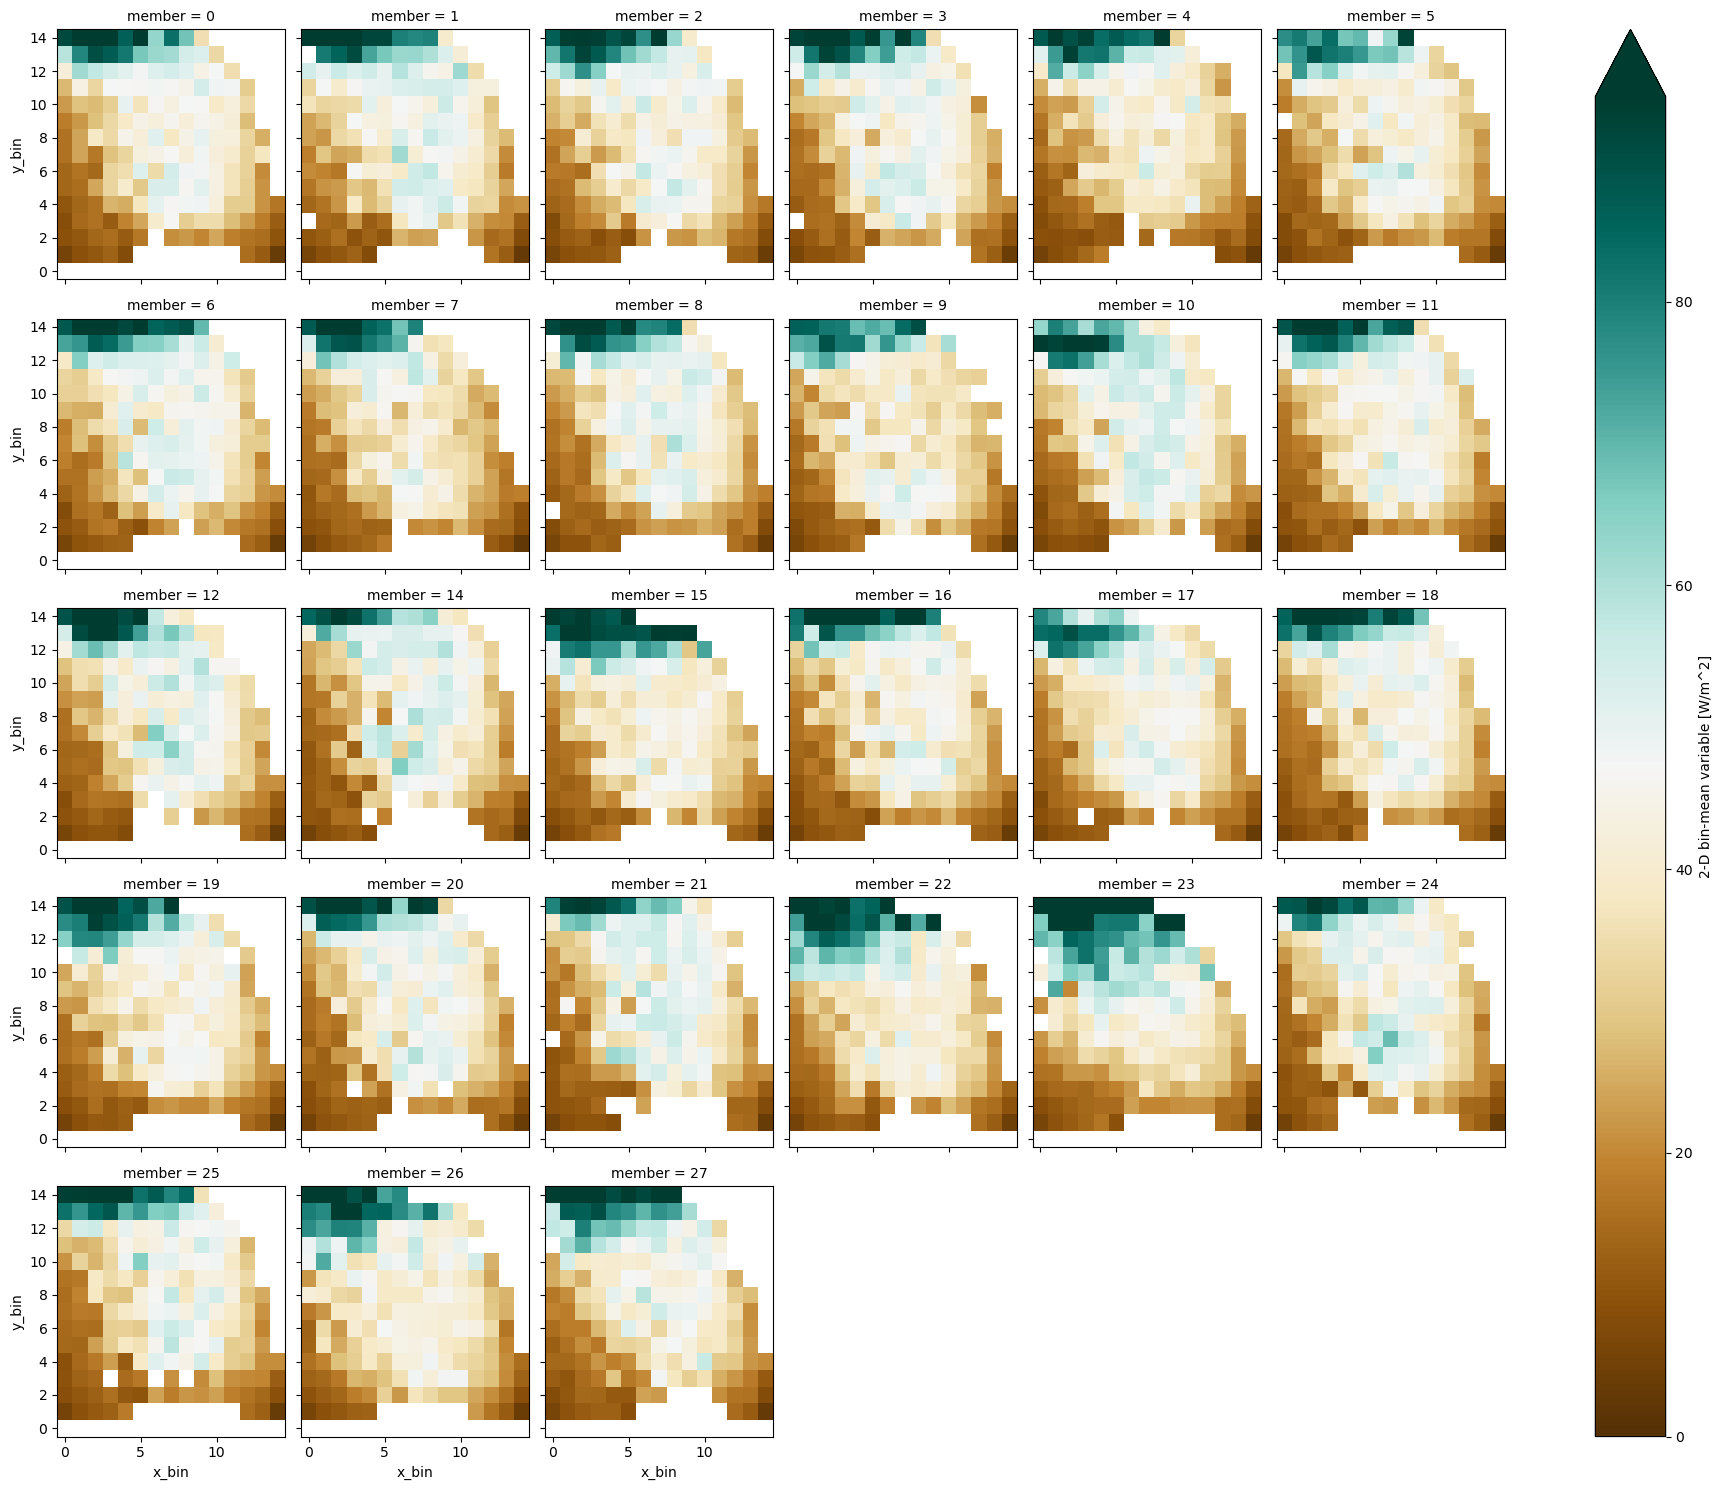

In [ ]:
fppe_bs.sel(stats="mean").plot(col="member", col_wrap=6, cmap="BrBG", vmin=0, robust=True)

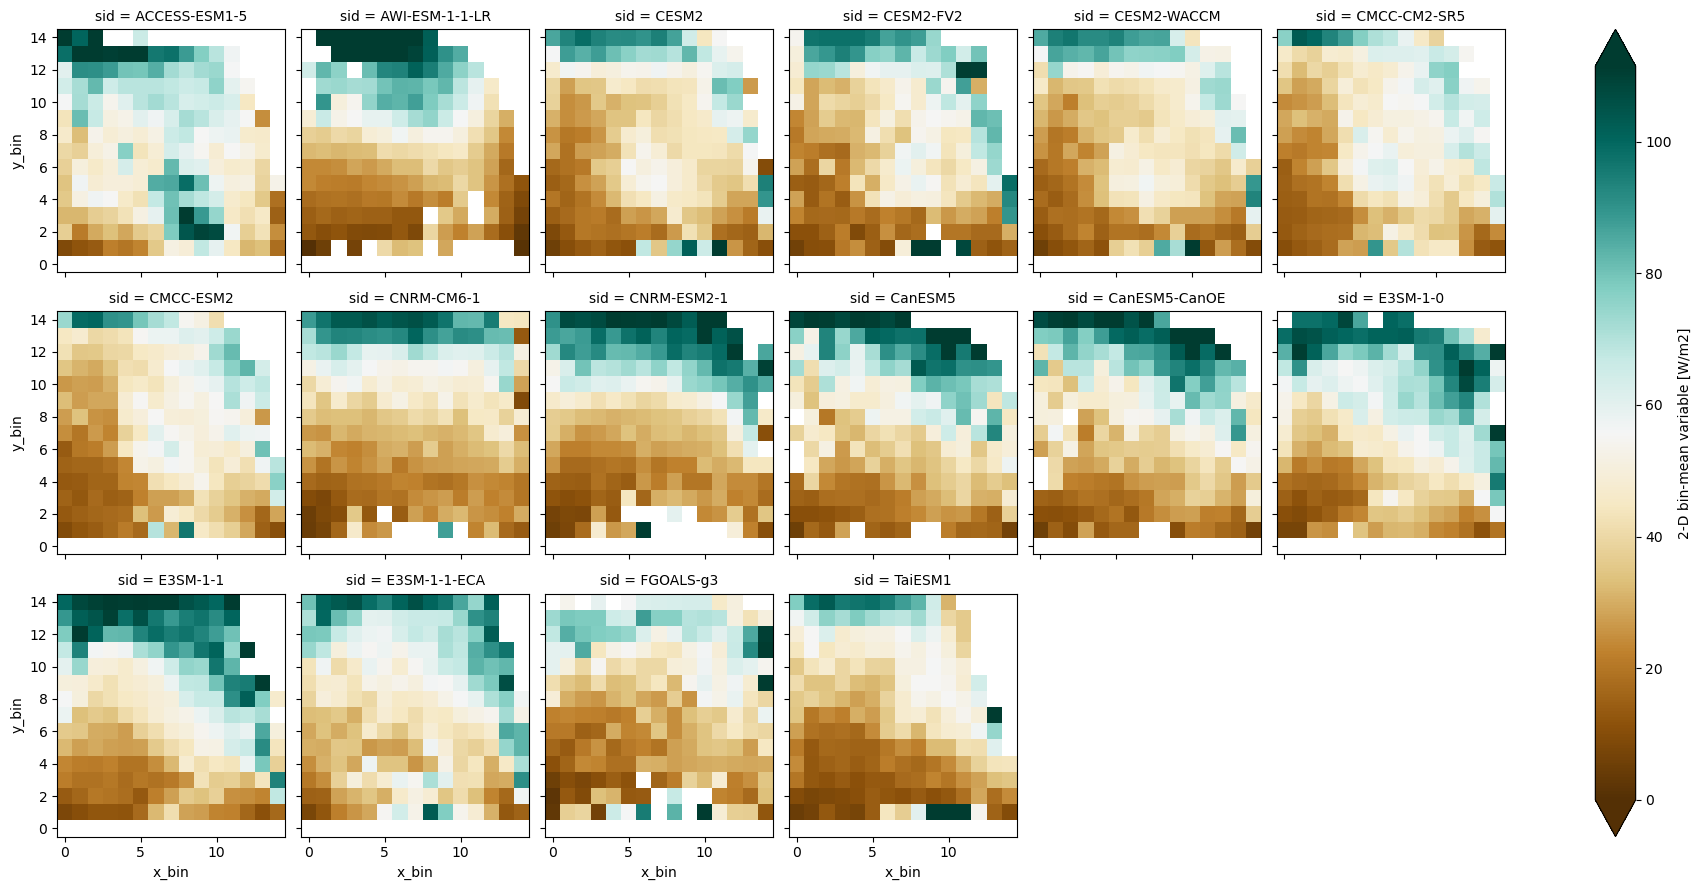

In [ ]:
cmip_bs.sel(stats="mean").plot(col="sid", col_wrap=6, cmap="BrBG", vmin=0, robust=True)

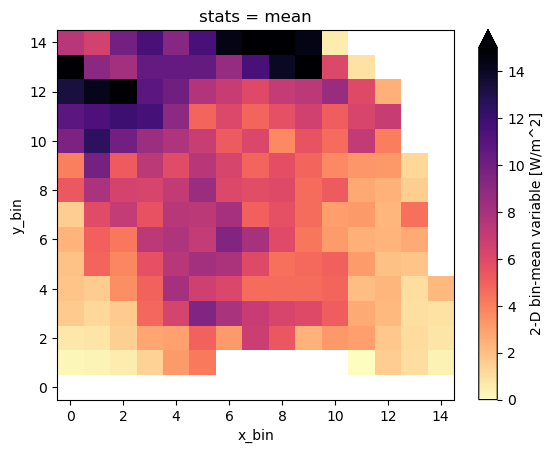

In [ ]:
fppe_bs.sel(stats="mean").std(dim="member").plot(cmap="magma_r", vmin=0, vmax=15)

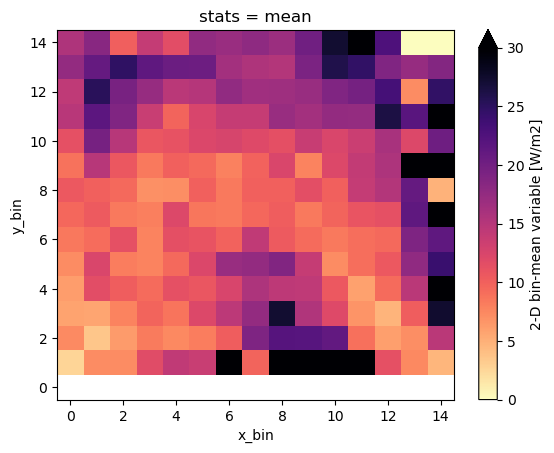

In [ ]:
cmip_bs.sel(stats="mean").std(dim="sid").plot(cmap="magma_r", vmin=0, vmax=30)

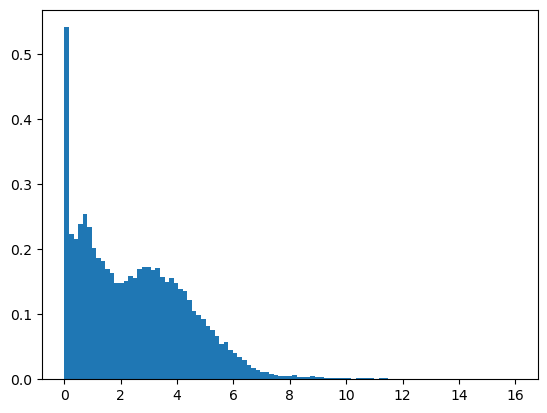

In [ ]:
plt.hist(lai_flat_all[~np.isnan(lai_flat_all) & (lai_flat_all >= 1e-3)], bins=np.linspace(0, 16, 100), density=True);

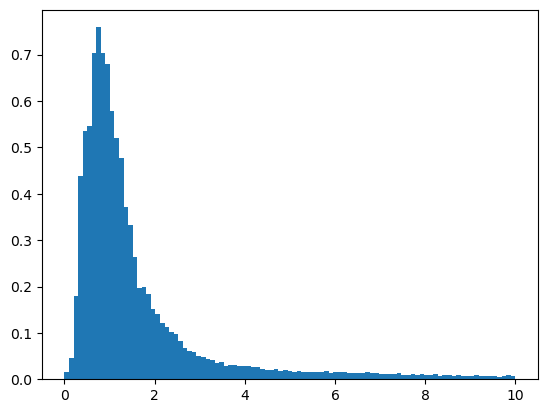

In [ ]:
plt.hist(ai_flat_all[~np.isnan(lai_flat_all)], bins=np.linspace(0, 10, 100), density=True);

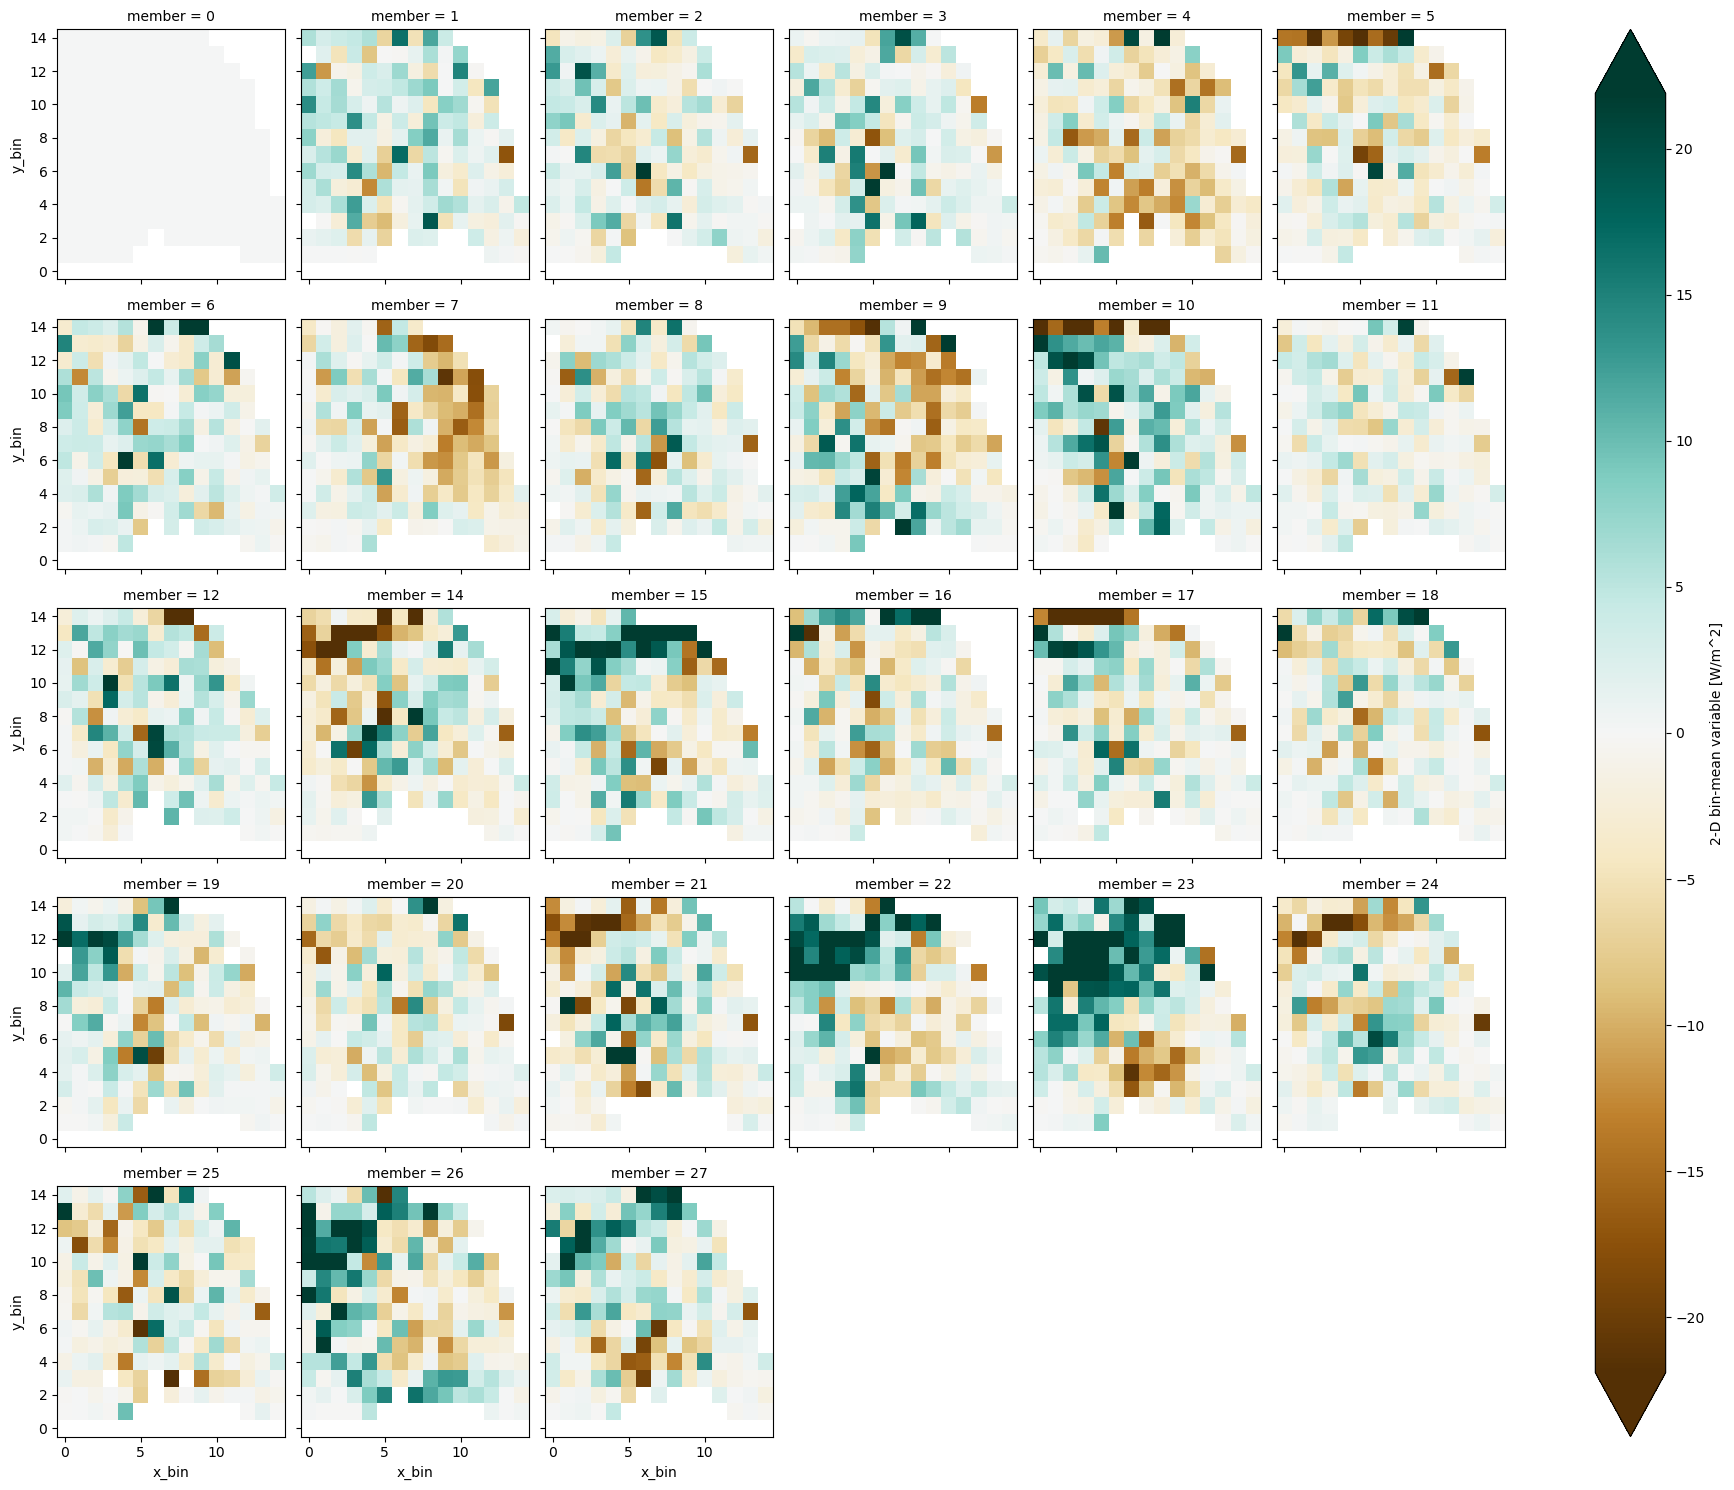

In [ ]:
(fppe_bs.sel(stats="mean") - fppe_bs.sel(member=0, stats="mean")).plot(col="member", col_wrap=6, cmap="BrBG", robust=True)

In [ ]:
# fppe_bs = xr.open_dataset("/glade/work/bbuchovecky/et_unc/proc/fppe/qbin/fppe.EFLX_LH_TOT.qbin_pooled.tgt-year.xvar-clim.yvar-year.198001-201412.nc")["EFLX_LH_TOT"]

In [ ]:
# fppe_bs.sel(stats="mean").plot(col="member", col_wrap=7, cmap="BrBG", robust=True)

In [ ]:
# fppe_bs.sel(stats="count").plot(col="member", col_wrap=6, cmap="magma_r", vmax=50000)

In [ ]:
# (fppe_bs.sel(stats="mean") - fppe_bs.sel(stats="mean", member=0)).plot(col="member", col_wrap=7, cmap="BrBG", vmin=-8, vmax=8)

In [ ]:
# cmip_bs_frac_sid = (xr.where(~np.isnan(cmip_bs.sel(stats="mean")), 1, 0).sum(dim="sid") / len(cmip_bs.sid))
# fppe_bs_frac_mem = (xr.where(~np.isnan(fppe_bs.sel(stats="mean")), 1, 0).sum(dim="member") / len(fppe_bs.member))

In [ ]:
# cmip_bs.sel(stats="mean").isel(y_bin=slice(1, None)).plot(col="sid", col_wrap=7, cmap="BrBG", vmin=0, robust=True)

In [ ]:
# fppe_bs.sel(stats="mean").isel(y_bin=slice(1, None)).plot(col="member", col_wrap=7, cmap="BrBG", vmin=0, vmax=110)

In [ ]:
# fppe_bs.sel(stats="count").sum(dim="y_bin").plot(col="member", col_wrap=7)

In [ ]:
# fppe_bs.sel(stats="count").sum(dim="x_bin").plot(col="member", col_wrap=7)

In [ ]:
# (fppe_bs.sel(stats="mean") / np.sqrt(fppe_bs.sel(stats="var_samp"))).plot(col="member", col_wrap=7, cmap="plasma_r", robust=False)#, cmap="magma_r")

In [ ]:
# (cmip_bs.sel(stats="count") / cmip_bs.sel(stats="count").sum(dim=["x_bin", "y_bin"])).isel(y_bin=slice(1, None)).plot(col="sid", col_wrap=7, cmap="magma_r", vmin=0, robust=True)

In [ ]:
# (fppe_bs.sel(stats="count") / fppe_bs.sel(stats="count").sum(dim=["x_bin", "y_bin"])).isel(y_bin=slice(1, None)).plot(col="member", col_wrap=7, cmap="magma_r", vmin=0, robust=True)

In [ ]:
# fppe_bs.sel(stats="mean").std(dim="member").where(fppe_bs_frac_mem>0.75).plot(robust=True)

In [ ]:
# cmip_bs.sel(stats="mean").std(dim="sid").where(cmip_bs_frac_sid>0.75).plot(robust=True)

In [ ]:
# fppe_bs.sel(stats="mean").mean(dim="member").where(fppe_bs_frac_sid>0.75).plot(robust=True)

In [ ]:
# cmip_bs.sel(stats="mean").mean(dim="sid").where(cmip_bs_frac_sid>0.75).plot(robust=True)

# End

In [57]:
if client_cluster is not None:
    xclim.close_dask_cluster(client_cluster, remove_std_files=True)